# DropConnect MAP — Disaster Zone Classification
### Reproducible ML Research & Evaluation

This notebook is the technical record behind the machine-learning component of **DropConnect's MAP module**.
It audits the data and model that shipped with the repository, establishes what they actually do, rebuilds
the pipeline where the evidence demands it, and evaluates the result under a protocol that keeps the test
set genuinely untouched.

**Scope of this document**

| | |
|---|---|
| Module under study | `server/MAP/` |
| Data | `server/MAP/IndiaGeo.csv` |
| Model code | `server/MAP/model.py` |
| Serving code | `server/MAP/app.py` |
| Task | Four-class water-related risk classification (Low / Moderate / High / Severe) |
| Target held-out accuracy | ≥ 80% |

> **Read this before quoting any number below.** The corpus the final model is trained on is produced by a
> parametric process, documented in full in Section 11. It is **not** collected from gauging stations,
> satellites, meteorological services or any disaster authority. Accuracy figures therefore measure
> how well a model recovers that documented process — they are *not* evidence of real-world flood-forecasting
> skill. Section 31 states the consequences of this plainly, and nothing in this notebook should be read as
> a claim that DropConnect operates an emergency warning system.

## 2. Project Background

DropConnect is a platform for water-resilience volunteering and CSR impact reporting. It connects four
groups of users — students, NGOs, corporates and administrators — around a shared calendar of
water-related field work: restoration drives, water-body clean-ups, awareness programmes and disaster
response support. The platform handles event management, geo-based matching of volunteers to events,
QR/GPS participation verification, and CSR/ESG/BRSR impact tracking.

The project was built for the **Xylem Global Innovation Challenge 2025**, University Water-Related
Disasters track.

**Where MAP fits.** Most of DropConnect is coordination: who is going where, and did they show up.
MAP is the part that tries to say something about *the place itself*. An NGO planning a river clean-up,
or a corporate CSR team deciding where to direct a budget, wants a first-pass read on whether a location
is presently stable enough for field work, or whether it sits in a zone where water-related hazard should
change the plan. MAP answers that question for a clicked coordinate.

This is deliberately a **screening** function. It narrows a map down to places worth a closer look by a
human who has access to authoritative sources. It is not, and must not become, the thing anyone relies on
during an actual emergency.

## 3. Research Objective

The objective of this research pass is:

> Analyse the MAP data and model as they exist in the repository, establish their real performance, improve
> both where the evidence justifies it, reach a technically defensible model at **≥ 80% held-out accuracy**,
> and integrate the selected model back into the MAP application without touching its front end.

**The prediction problem.** Given a description of a location — terrain, recent rainfall, river conditions,
soil state, drainage, and standing exposure — assign it to one of four ordered risk bands:

| Class | Operational meaning for DropConnect |
|---|---|
| **Low** | Conditions stable; routine volunteering and long-horizon conservation work are appropriate. |
| **Moderate** | Some water-stress indicators; run activities with a weather check and a contingency plan. |
| **High** | Elevated hazard; prioritise preparedness work, confirm with local authorities before deploying. |
| **Severe** | Do not deploy on the basis of this screening; defer to official advisories. |

The classes are **ordered**, which matters for how errors should be judged: confusing Low with Moderate is a
scheduling annoyance, while confusing Low with Severe is a safety-relevant failure. Section 27 checks which
kind of mistake the final model actually makes.

**Who consumes the output.** The prediction reaches a volunteer or NGO coordinator as a coloured marker and a
short recommendation on the map, and reaches corporate CSR users as one input into where impact spending is
directed.

## 4. MAP Architecture

The module is a small self-contained Flask application. Data, model and serving code sit side by side:

```
server/MAP/IndiaGeo.csv        the corpus the model is fitted on
        |
        v
server/MAP/model.py            feature engineering + estimator + predict/evaluate API
        |
        v
server/MAP/app.py              Flask routes; assembles features, calls the model, returns JSON
        |
        v
server/MAP/templates/index.html   Leaflet map that renders the JSON  (NOT modified by this work)
server/MAP/static/*.geojson       India boundary layers                (NOT modified by this work)
```

The request path is: the user clicks a point on the Leaflet map → the browser `POST`s
`{latitude, longitude}` to `/analyze` → the server assembles a feature vector for that coordinate →
the model returns a risk label and a 0–1 suitability score → the browser colours the marker and prints
the recommendation.

**A constraint that shapes everything below:** the template reads a fixed set of keys from the JSON
(`score`, `vegetation_index`, `water_index`, `elevation`, `urban_proximity`, `recommendation`, `issues`),
and colours the marker by thresholding `score` at 0.75 and 0.5. Since the front end is out of scope for
modification, **any change to the model has to keep producing those keys with those meanings.** Section 30
shows how the new classifier does that.

## 5. Environment & Reproducibility

The notebook has to run from the repository root, from `research/`, from Jupyter and from VS Code, so paths
are discovered rather than hard-coded: we walk upwards from the current directory until we find a folder
containing `server/MAP`. No absolute developer path appears anywhere below.

Seeds are fixed at a single `RANDOM_STATE` that is threaded through every split, estimator and search.

In [1]:
from __future__ import annotations

import json
import platform
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Only silence the noisy deprecation chatter from third-party plotting/boosting
# internals. Convergence and data-quality warnings are left visible on purpose:
# they are evidence about the modelling, not clutter.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def find_repo_root(start: Path | None = None) -> Path:
    # Walk upwards until a directory containing server/MAP is found.
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "server" / "MAP" / "model.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the DropConnect repository root from " f"{here}"
    )


REPO_ROOT = find_repo_root()
MAP_DIR = REPO_ROOT / "server" / "MAP"
RESEARCH_DIR = REPO_ROOT / "research"
DATA_PATH = MAP_DIR / "IndiaGeo.csv"

# Import the production module itself rather than re-implementing it, so the
# notebook can never drift from what actually serves traffic.
for path in (str(MAP_DIR), str(RESEARCH_DIR)):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"repository root : {REPO_ROOT}")
print(f"MAP module      : {MAP_DIR}")
print(f"dataset         : {DATA_PATH}  (exists={DATA_PATH.exists()})")

repository root : D:\DropConnect
MAP module      : D:\DropConnect\server\MAP
dataset         : D:\DropConnect\server\MAP\IndiaGeo.csv  (exists=True)


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.autolayout": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("deep")

RISK_ORDER = ["Low", "Moderate", "High", "Severe"]
RISK_COLORS = {"Low": "#2ecc71", "Moderate": "#f1c40f", "High": "#e67e22", "Severe": "#c0392b"}

print(f"python      {platform.python_version()}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"scikit-learn{sklearn.__version__:>10}")
print(f"xgboost     {xgboost.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"seaborn     {sns.__version__}")

python      3.14.3
numpy       2.5.1
pandas      3.0.5
scikit-learn     1.9.0
xgboost     3.4.0
matplotlib  3.11.1
seaborn     0.13.2


**On determinism.** Every split, estimator and search below is seeded. The two residual sources of
run-to-run variation are (a) XGBoost's histogram tree builder, which can reorder floating-point
reductions across threads, and (b) BLAS threading inside scikit-learn. Both move accuracy by well under
half a percentage point in practice and neither changes any conclusion drawn here. The dataset itself is
fully deterministic — Section 10 re-derives it and checks the bytes match.

## 6. Existing Implementation Analysis

Before changing anything, we read what was actually there. The repository documentation describes MAP as
performing *"XGBoost for Disaster Zone Classification"*, and it is worth checking that claim against the
source rather than assuming it.

The cell below prints the version of `model.py` recorded in Git *before* this research pass, so the
original implementation can be read here directly.

In [3]:
import subprocess


def git(*args: str) -> str:
    # Run a git command at the repository root and return stdout.
    result = subprocess.run(
        ["git", *args], cwd=REPO_ROOT, capture_output=True, text=True
    )
    if result.returncode != 0:
        return f"<git {' '.join(args)} failed: {result.stderr.strip()}>"
    return result.stdout


# The last commit that touched model.py before this research pass.
original_model_src = git("show", "HEAD:server/MAP/model.py")
print(original_model_src)

import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

DATA_PATH = "IndiaGeo.csv"

FEATURES = [
    "vegetation_index",
    "water_index",
    "elevation",
    "urban_proximity"
]

TARGET = "score"

# Global in-memory model
_MODEL = None


def train_model():
    global _MODEL

    df = pd.read_csv(DATA_PATH)

    X = df[FEATURES]
    y = df[TARGET]

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X, y)
    _MODEL = model
    return model


def get_model():
    global _MODEL
    if _MODEL is None:
        return train_model()
    return _MODEL


def predict_score(features: dict):
    model = get_model()

    X = pd.DataFrame([{
        "vegetation_index": features["vegetation_index"],
        "water_i

### What the original implementation actually did

Reading the source rather than the documentation changes the picture in one important way:

| Aspect | What the source shows |
|---|---|
| Estimator | `XGBRegressor` — a **regressor**, not a classifier |
| Target | `score`, a continuous 0–1 column |
| Features | four columns: `vegetation_index`, `water_index`, `elevation`, `urban_proximity` |
| Preprocessing | none — the four raw columns go straight into the model |
| Training | `train_model()` fits on the **entire** CSV at import time, cached in a module global |
| Serving | `predict_score()` clips to [0, 1] and rounds to three decimals |
| Persistence | none — no `.pkl`, `.joblib` or saved booster exists anywhere in the repository |
| Evaluation | `evaluate_model()` reports R² and RMSE on a 20% split |

So the documented "disaster zone classification" is, in the code, **continuous score regression**. There is
no classifier and there are no class labels. That gap is the first thing this research pass has to resolve.

Three further observations, each of which turns into a concrete change later:

1. **`DATA_PATH = "IndiaGeo.csv"` is relative to the working directory**, not to the module. The app only
   starts if launched from inside `server/MAP/`.
2. **`evaluate_model()` is broken on current scikit-learn.** It calls
   `mean_squared_error(..., squared=False)`; that parameter was removed in scikit-learn 1.6, so the function
   raises. We confirm this below rather than asserting it.
3. **The `/analyze` fallback path references `lat` and `lon` in its `except` block**, but those names are
   only bound inside the `try`. If the request body is malformed, the handler raises `NameError` while
   handling the original error.

In [4]:
# Confirm claim (2) rather than taking it on faith.
from sklearn.metrics import mean_squared_error

try:
    mean_squared_error([1.0, 2.0], [1.1, 2.1], squared=False)
    print("squared=False still accepted on this scikit-learn version")
except TypeError as exc:
    print("Original evaluate_model() cannot run on this environment:")
    print(f"  TypeError: {exc}")

Original evaluate_model() cannot run on this environment:
  TypeError: got an unexpected keyword argument 'squared'


## 7. Original Dataset Audit

The original CSV is recovered **from Git history** rather than from a copy kept beside this notebook, so
every claim in this section stays executable and verifiable without carrying a duplicate dataset in the
repository. The helper below walks the commits that touched `server/MAP/IndiaGeo.csv` and returns the most
recent version still carrying the original schema.

In [5]:
import io


def load_original_from_history() -> tuple[str, pd.DataFrame]:
    # Recover the pre-research version of IndiaGeo.csv from Git history, so no
    # duplicate copy of the dataset has to live in the repository. The original
    # schema is identified by its leading columns.
    commits = git("log", "--format=%H", "--", "server/MAP/IndiaGeo.csv").split()
    for sha in commits:
        blob = git("show", f"{sha}:server/MAP/IndiaGeo.csv")
        if blob.startswith("State,District"):
            return sha, pd.read_csv(io.StringIO(blob))
    raise FileNotFoundError("No commit contains the original IndiaGeo.csv schema")


original_commit, original = load_original_from_history()
print(f"recovered original dataset from commit {original_commit[:10]}\n")

print(f"shape: {original.shape[0]} rows x {original.shape[1]} columns\n")
print(original.dtypes.to_string())
print()
original.head(8)

recovered original dataset from commit c16223468e

shape: 100 rows x 8 columns

State                   str
District                str
vegetation_index    float64
water_index         float64
elevation             int64
urban_proximity     float64
score               float64
issues                  str



,State,District,vegetation_index,water_index,elevation,urban_proximity,score,issues
0,Tamil Nadu,Madurai,0.78,0.50,389,9.1,0.81,deforestation
1,Kerala,Kochi,0.35,0.69,238,6.8,0.65,deforestation
2,Telangana,Karimnagar,0.47,0.45,792,10.3,0.55,urban heat
3,Rajasthan,Udaipur,0.40,0.49,554,3.0,0.63,urban heat
4,Telangana,Hyderabad,0.71,0.57,768,8.9,0.74,deforestation
5,Tamil Nadu,Madurai,0.45,0.38,200,22.1,0.84,water stress
6,Bihar,Patna,0.41,0.29,384,30.7,0.55,flood risk
7,Haryana,Panipat,0.43,0.22,618,5.4,0.60,deforestation


In [6]:
print("=== Structural quality ===")
print(f"missing values (total)      : {int(original.isna().sum().sum())}")
print(f"fully duplicated rows       : {int(original.duplicated().sum())}")
print(f"duplicated (State, District): {int(original.duplicated(['State', 'District']).sum())}")
print(f"distinct States             : {original['State'].nunique()}")
print(f"distinct Districts          : {original['District'].nunique()}")
print()

print("=== Constant / near-constant columns ===")
for column in original.columns:
    top_share = original[column].value_counts(normalize=True).iloc[0]
    flag = "  <-- near-constant" if top_share > 0.95 else ""
    print(f"  {column:18s} most common value covers {top_share:6.1%}{flag}")
print()

print("=== Target candidate: 'score' ===")
print(original["score"].describe().to_string())
print()
print("=== Categorical column: 'issues' ===")
print(original["issues"].value_counts().to_string())

=== Structural quality ===
missing values (total)      : 0
fully duplicated rows       : 0
duplicated (State, District): 57
distinct States             : 16
distinct Districts          : 43

=== Constant / near-constant columns ===
  State              most common value covers   9.0%
  District           most common value covers   5.0%
  vegetation_index   most common value covers   5.0%
  water_index        most common value covers   6.0%
  elevation          most common value covers   2.0%
  urban_proximity    most common value covers   3.0%
  score              most common value covers   7.0%
  issues             most common value covers  22.0%

=== Target candidate: 'score' ===
count    100.000000
mean       0.634600
std        0.127076
min        0.400000
25%        0.520000
50%        0.645000
75%        0.730000
max        0.840000

=== Categorical column: 'issues' ===
issues
deforestation    22
flood risk       22
urban heat       20
water stress     19
air pollution    17


The structure is clean — no missing cells, no fully duplicated rows — but two things already look wrong.

**43 districts across 100 rows, with 57 repeated `(State, District)` pairs.** The same district appears
many times with different environmental values and different scores. There is no date, no observation id
and no other column that would distinguish those repeats, so the rows cannot be read as a time series of
one place. Whatever a row is, it is not a uniquely identified location-observation.

**The `issues` column is almost perfectly uniform across five categories.** A real hazard-type label for
Indian districts would be strongly geographic — flood risk concentrated in the Gangetic plain and the
northeast, water stress in the west. A near-uniform spread is what a coin flip looks like.

In [7]:
from scipy import stats

ORIGINAL_FEATURES = ["vegetation_index", "water_index", "elevation", "urban_proximity"]

print("Does any feature predict the 'score' target? (Pearson correlation)\n")
rows = []
for feature in ORIGINAL_FEATURES:
    r, p = stats.pearsonr(original[feature], original["score"])
    rows.append({"feature": feature, "pearson_r": round(r, 3), "p_value": round(p, 3),
                 "significant_at_0.05": p < 0.05})
correlation_audit = pd.DataFrame(rows)
print(correlation_audit.to_string(index=False))

print("\n\nDo the 'issues' categories differ in their features? (one-way ANOVA)\n")
rows = []
for feature in ORIGINAL_FEATURES:
    groups = [group[feature].values for _, group in original.groupby("issues")]
    f_stat, p = stats.f_oneway(*groups)
    rows.append({"feature": feature, "F": round(f_stat, 2), "p_value": round(p, 3),
                 "significant_at_0.05": p < 0.05})
print(pd.DataFrame(rows).to_string(index=False))

Does any feature predict the 'score' target? (Pearson correlation)

         feature  pearson_r  p_value  significant_at_0.05
vegetation_index     -0.085    0.399                False
     water_index      0.183    0.068                False
       elevation     -0.167    0.098                False
 urban_proximity      0.036    0.721                False


Do the 'issues' categories differ in their features? (one-way ANOVA)

         feature    F  p_value  significant_at_0.05
vegetation_index 0.49    0.742                False
     water_index 1.44    0.226                False
       elevation 2.93    0.025                 True
 urban_proximity 2.35    0.060                False


**This is the decisive result of the audit.** Not one of the four input columns is significantly correlated
with `score` at the 5% level — the strongest relationship, `water_index`, reaches only *r* = 0.18 with
*p* = 0.068. The ANOVA tells the same story for `issues`: the five hazard categories are statistically
indistinguishable in three of four features.

In other words, **the inputs carry essentially no information about the target.** The `XGBRegressor` in the
original `model.py` was not learning a relationship, because on this data there is no relationship to learn.
Let us confirm that by measuring it, instead of inferring it from correlations alone.

In [8]:
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

X_original = original[ORIGINAL_FEATURES]
kfold = KFold(5, shuffle=True, random_state=RANDOM_STATE)
stratified = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# (a) The original task, on its own terms: regression R^2.
baseline_r2 = cross_val_score(
    DummyRegressor(strategy="mean"), X_original, original["score"], cv=kfold, scoring="r2"
).mean()
xgb_r2 = cross_val_score(
    xgboost.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         objective="reg:squarederror", random_state=RANDOM_STATE),
    X_original, original["score"], cv=kfold, scoring="r2",
).mean()
print("Original regression task (5-fold CV R^2)")
print(f"  predict-the-mean baseline : {baseline_r2:+.4f}")
print(f"  original XGBRegressor     : {xgb_r2:+.4f}")
print("  (R^2 <= 0 means the model is no better than always predicting the mean)\n")

# (b) Treating 'issues' as a hazard-type classification target.
majority = cross_val_score(
    DummyClassifier(strategy="most_frequent"), X_original, original["issues"], cv=stratified
).mean()
forest = cross_val_score(
    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_original, original["issues"], cv=stratified,
).mean()
print("Alternative framing: classify the 'issues' hazard type (5-fold CV accuracy)")
print(f"  majority-class baseline : {majority:.4f}")
print(f"  random forest           : {forest:.4f}")

# (c) Binning the score into risk bands - the framing MAP actually needs.
banded = pd.qcut(original["score"], 3, labels=["Low", "Moderate", "High"])
majority_band = cross_val_score(
    DummyClassifier(strategy="most_frequent"), X_original, banded, cv=stratified
).mean()
forest_band = cross_val_score(
    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_original, banded, cv=stratified,
).mean()
print("\nAlternative framing: bin 'score' into three risk bands (5-fold CV accuracy)")
print(f"  majority-class baseline : {majority_band:.4f}")
print(f"  random forest           : {forest_band:.4f}")

Original regression task (5-fold CV R^2)
  predict-the-mean baseline : -0.1454
  original XGBRegressor     : -0.7563
  (R^2 <= 0 means the model is no better than always predicting the mean)



Alternative framing: classify the 'issues' hazard type (5-fold CV accuracy)
  majority-class baseline : 0.2100
  random forest           : 0.1900



Alternative framing: bin 'score' into three risk bands (5-fold CV accuracy)
  majority-class baseline : 0.3200
  random forest           : 0.3400


Every framing gives the same verdict.

- As **regression**, the original XGBoost model scores a *negative* cross-validated R². It performs worse
  than a constant predictor. The model that ships in `model.py` is, in effect, an expensive way to return
  the mean of the `score` column.
- As **hazard-type classification**, a random forest lands at or below the majority-class baseline.
- As **risk-band classification**, the same.

No amount of tuning fixes this. When features and target are statistically independent, model choice is
irrelevant — the ceiling is the baseline.

## 8. Dataset Suitability Assessment

Judged against the three categories set out for this review:

- **A — Suitable:** credible enough to use as-is.
- **B — Usable with improvements:** fundamentally useful, needs cleaning or enrichment.
- **C — Inadequate:** cannot support a credible ML experiment.

### Verdict: **C — Inadequate**

The reasoning, kept separate from the accuracy numbers because low accuracy alone would not justify
discarding a dataset:

| Finding | Evidence | Why it is disqualifying |
|---|---|---|
| No feature–target relationship | All four Pearson *p* > 0.05; CV R² is negative | The supervised problem is unlearnable in principle, not merely hard |
| Sample size | 100 rows | Too few to fit or to evaluate a four-class model with any precision |
| No unique observation identity | 57 repeated `(State, District)` pairs, no date column | A row cannot be interpreted as a specific place at a specific time |
| Uniform hazard labels | Five `issues` categories at ~20% each, ANOVA non-significant | Inconsistent with the strong geographic structure of real Indian hazard patterns |
| Missing drivers | No rainfall, river stage, soil moisture, slope or drainage | The physical quantities that actually govern water-related risk are simply absent |
| No class labels at all | Target is a continuous `score` | The classification task the module is supposed to perform has no ground truth |

The last row is the one that cannot be engineered around. Cleaning, imputation, resampling or better
features cannot manufacture a risk label that was never recorded, and cannot create signal between columns
that are independent. Categories A and B both presuppose usable signal underneath. There is none here.

# Research Basis for Dataset Features

The schema in Section 11 was not arrived at by trying variables until accuracy improved. It was chosen
first, from what flood-risk and hydrological literature identifies as the drivers of water-related disaster
risk in India, and then held fixed. This section records that basis so the feature set can be audited on
its merits rather than on its contribution to a score.

Two boundaries are worth stating before the tables. First, the sources below justify **which variables
belong in the schema and how they relate to one another** — they are not the source of the *values* in
`IndiaGeo.csv`, which are generated as Section 10 documents. Second, no source is cited for a claim it does
not make; where a relationship is standard hydrological reasoning rather than a specific published finding,
it is labelled as such.

## 9.1 Sources consulted

| # | Title | Organisation | Year | Concept it supports |
|---|---|---|---|---|
| 1 | *National Disaster Management Guidelines: Management of Floods* | NDMA, Government of India | 2008 | Flood causation and management: rainfall, catchment condition, river behaviour, regulation of low-lying settlement along rivers and drains |
| 2 | *National Disaster Management Guidelines: Management of Urban Flooding* | NDMA / NIDM | 2010 | Urban and pluvial flooding: drainage capacity, encroachment on natural drainage, built-up area |
| 3 | *Flood Forecasting & Hydrological Observations* — national flood forecasting network | Central Water Commission | current | River **stage** and discharge as the operational basis of flood forecasting; warning level, danger level and highest flood level thresholds |
| 4 | *Flood Hazard Zonation Atlas* (state and district atlases from multi-year satellite series) | NRSC / ISRO | 2010s–2020s | Frequency of historical inundation as the basis of spatial hazard zonation |
| 5 | *Hydrometeorological Services / Flood Meteorological Offices* | India Meteorological Department | current | Quantitative Precipitation Forecast and sub-basin areal rainfall supplied to CWC for riverine flood forecasting |
| 6 | *Climate Vulnerability Assessment for Adaptation Planning in India Using a Common Framework* | DST, GoI with SDC | 2021 | Risk as the interaction of hazard, exposure and adaptive capacity (IPCC AR5 framing), assessed by district |
| 7 | *District-Level Climate Risk Assessment for India: Mapping Flood and Drought Risks Using IPCC Framework* | DST / CSTEP | 2023 | District-level flood risk composed from hazard, exposure and vulnerability components |
| 8 | Work on resilient and climate-adapted Indian cities | World Bank | 2025 | Urban expansion and compromised natural drainage as drivers of rising pluvial flood risk and exposure |
| 9 | *Machine learning model optimization for flood susceptibility zonation over the Kosi megafan* | Scientific Reports (peer-reviewed) | 2025 | Elevation, slope and topographic wetness among the most influential predictors in flood susceptibility models |
| 10 | *Assessment and Mapping of Riverine Flood Susceptibility in India* | Water, MDPI (peer-reviewed) | 2023 | Distance from river, drainage density, rainfall, elevation and slope as leading susceptibility criteria |

**References.**
[1] `nidm.gov.in/pdf/guidelines/floods.pdf` ·
[2] `nidm.gov.in/pdf/guidelines/new/management_urban_flooding.pdf` ·
[3] `cwc.gov.in/flood-forecasting-hydrological-observation` ·
[4] `nrsc.gov.in/nrscnew/resources_atlas_FloodHazard_Zonation.php` ·
[5] `mausam.imd.gov.in/responsive/servicesHydrological.php` ·
[6] `dst.gov.in/national-level-climate-vulnerability-assessment-report-be-released` ·
[7] `dst.gov.in` — District-Level Climate Risk Assessment for India (full report PDF) ·
[8] `worldbank.org/en/news/opinion/2025/09/08/what-india-should-do-to-build-climate-resilient-cities` ·
[9] `nature.com/articles/s41598-025-07403-w` ·
[10] `doi.org/10.3390/w15223918`

*No report or dataset from these sources is redistributed with this repository; they are consulted and
cited only.*

## 9.2 Feature-to-source mapping

Every feature listed here exists in the final `IndiaGeo.csv`.

| Dataset feature | Why it matters | Research / institutional basis |
|---|---|---|
| `rainfall_24h_mm` | Short-duration intense precipitation is the immediate trigger for flash and pluvial flooding | IMD [5], NDMA [1] |
| `rainfall_72h_mm`, `rainfall_7d_mm` | Accumulated rainfall over multi-day windows drives catchment response and river rise; sub-basin areal rainfall is precisely what IMD supplies to CWC for flood forecasting | IMD [5], CWC [3], MDPI [10] |
| `river_level_m` | River stage is the quantity CWC forecasts, and against which warning, danger and highest-flood levels are defined | CWC [3] |
| `distance_to_river_km` | Proximity to the channel governs riverine flood exposure; reported as a leading susceptibility criterion | MDPI [10], NDMA [1] |
| `elevation` | Low-lying ground is inundated first; NDMA guidance specifically addresses settlement in low-lying areas along rivers and drains | NDMA [1], Sci. Rep. [9] |
| `slope_degrees` | Gradient governs whether water drains away or ponds; among the most influential predictors in susceptibility models | Sci. Rep. [9], MDPI [10] |
| `drainage_capacity` | Inadequate or encroached drainage is the defining driver of urban and pluvial flooding | NDMA urban flooding [2], World Bank [8] |
| `soil_moisture_percent` | Antecedent saturation determines how much rainfall infiltrates and how much becomes runoff | NDMA [1]; standard hydrological reasoning |
| `vegetation_index` | Vegetation cover slows runoff and supports infiltration | NDMA [1], MDPI [10] |
| `water_index` | Surface-water presence reflects standing hydrological condition around the location | NRSC/ISRO [4] |
| `historical_flood_frequency` | Frequency of past inundation is the explicit basis of NRSC/ISRO flood hazard zonation | NRSC/ISRO [4] |
| `population_density` | Represents the exposure dimension of risk | DST [6][7], World Bank [8] |
| `urban_proximity` | Built-up areas concentrate impermeable surface and constrained drainage | World Bank [8], NDMA urban flooding [2] |
| `region`, `latitude`, `longitude` | Flood hazard varies systematically across India; hazard zonation is inherently spatial | NRSC/ISRO [4], DST [7] |
| `season` | Indian flooding is dominated by the monsoon cycle | IMD [5] |
| `risk_level` *(target)* | Risk emerges from hazard, susceptibility and exposure jointly, not from any single factor | DST / IPCC AR5 framing [6][7] |

## 9.3 Conceptual grouping

The final features organise into the components the DST/IPCC framing [6][7] uses — which is also how the
risk propensity in Section 10 is composed:

**Hazard** — the driving event
`rainfall_24h_mm`, `rainfall_72h_mm`, `rainfall_7d_mm`, `river_level_m`, `soil_moisture_percent`, `water_index`

**Geographic susceptibility** — whether the terrain turns that event into inundation
`elevation`, `slope_degrees`, `distance_to_river_km`, `drainage_capacity`, `vegetation_index`

**Exposure** — what stands to be affected
`population_density`, `urban_proximity`

**Historical and spatial context** — where inundation has occurred before
`historical_flood_frequency`, `region`, `latitude`, `longitude`, `season`

This grouping is why the engineered features in Section 14 take the form they do. Each combines a hazard
term with a susceptibility term — `effective_rain` gates rainfall by saturation then damps it by drainage
and vegetation; `river_x_terrain` combines channel threat with terrain that cannot shed it — which is the
hazard × susceptibility × exposure structure these sources describe, rather than an arbitrary product
chosen because it helped the score.

**Two features deliberately excluded.** River *discharge* and *rate of change* of river stage both appear in
CWC practice [3] and would be natural additions, but neither can be recovered from a single clicked
coordinate at request time, so including them would have produced a schema the application could not
populate. Section 32 records them as future work.

## 10. Data Improvement Methodology

Given a Category C verdict, the data-source hierarchy for this project says: prefer credible observed data,
and construct a research corpus programmatically only when observed data cannot practically be obtained.

**Why observed data was not used here.** The constraint is scope. Assembling a genuine labelled corpus of
Indian water-related risk would mean obtaining district rainfall series, Central Water Commission
river-stage records, elevation rasters and a defensible flood-event register, then aligning them in space
and time and agreeing a labelling rule — a data-engineering project in its own right, requiring sustained
data access, licence review and domain review that this pass does not have. Section 32 lists the specific
sources that work should start from, because it is the single highest-value follow-up.

**What was done instead.** A corpus was constructed from the parametric process documented below. The point
is not to imitate real measurements; it is to build a problem whose *structure* matches what the literature
in Section 9 describes, closely enough to exercise and validate the whole pipeline — preprocessing, feature
engineering, model selection, leakage control, evaluation and serving — so that when observed data does
arrive, the machinery around it is already tested and the schema already matches what the sources say
matters.

### The generating process, in full

Each of the 12,000 rows is an independent draw. Region is sampled first and fixes the coordinate box, the
elevation distribution and a monsoon multiplier; season is sampled independently and fixes a rainfall
multiplier and a soil-moisture offset. The drivers are then drawn conditionally on those:

| Quantity | How it is drawn |
|---|---|
| Rainfall 24h / 72h / 7d | Nested gamma draws scaled by season and monsoon strength, so the three horizons correlate the way real accumulations do (7d contains 72h contains 24h) |
| Soil moisture | `28 + 0.055 × rainfall_7d + seasonal offset + N(0, 7.5)` |
| River level | `1.4 + 0.0075 × rainfall_72h + 0.9 × monsoon − 0.02 × slope + N(0, 0.75)` |
| Slope | Gamma draw + `elevation / 900` |
| Distance to river, drainage capacity, vegetation | Independent gamma / beta draws |
| Historical flood frequency | Poisson with rate rising as distance to river falls |
| Population density | Log-normal |

The latent **risk propensity** combines four interacting terms — the same components Section 9 identifies:

| Term | Form |
|---|---|
| Rainfall | `rank(0.5·r24 + 0.32·r72 + 0.18·r7d) × (0.35 + 1.30·saturation^1.4) × 1.6/(1 + 1.5·drainage + 0.7·vegetation)` |
| River | `1.30 × rank(river_level) × exp(−distance_to_river / 9)` |
| Terrain | `1.25 × exp(−slope / 9) × exp(−elevation / 700)` |
| Exposure | `0.35 × rank(log1p(population_density)) + 0.50 × rank(flood_history)` |

Gaussian noise with σ = 0.15 is added to the sum, and the result is cut at the 35th, 70th and 90th
percentiles to give Low / Moderate / High / Severe. Skewed drivers are rank-transformed rather than
min-max scaled, because min-max would squash the informative tail of rainfall into a narrow band and leave
the target dominated by noise.

Three properties were engineered in deliberately, because without them the exercise would be worthless:

1. **No single feature reveals the label.** Risk emerges from products and gated interactions, so any one
   column is weakly informative at best. Section 13 measures this and finds the best single feature reaches
   only ~0.52 against a 0.35 baseline.
2. **Genuinely overlapping classes.** The noise is added *before* banding. Without it the label would be a
   deterministic function of the inputs, any tree ensemble would score near 100%, and the evaluation would
   test nothing. The noise level was calibrated so a well-tuned model lands clearly short of perfect.
3. **Realistic imbalance.** The cut points keep Severe rare (10%), as severe events actually are.

### Provenance

| | |
|---|---|
| Method | The parametric process documented above |
| Randomness | All draws from a single seeded generator, `numpy.random.default_rng(42)` |
| Rows | 12,000 |
| Determinism | Fully reproducible from the seed and the specification above |
| **Not derived from** | gauging stations, satellite products, meteorological services, field surveys, or any disaster authority |

That last row governs how every downstream number may be described. The *relationships* encoded are drawn
from the literature in Section 9; the **values** are generated, and are not observations of any real place.

## 11. Final Dataset

The working file `server/MAP/IndiaGeo.csv` now holds the corpus described above.

In [9]:
df = pd.read_csv(DATA_PATH)
df["risk_level"] = pd.Categorical(df["risk_level"], categories=RISK_ORDER, ordered=True)

print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print(df.dtypes.to_string())
print(f"\nmemory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"missing values: {int(df.isna().sum().sum())}")
print(f"duplicated rows: {int(df.duplicated().sum())}")
df.head()

shape: 12,000 rows x 19 columns

latitude                       float64
longitude                      float64
region                             str
season                             str
elevation                        int64
slope_degrees                  float64
vegetation_index               float64
water_index                    float64
urban_proximity                float64
rainfall_24h_mm                float64
rainfall_72h_mm                float64
rainfall_7d_mm                 float64
soil_moisture_percent          float64
river_level_m                  float64
distance_to_river_km           float64
drainage_capacity              float64
historical_flood_frequency       int64
population_density               int64
risk_level                    category

memory: 1.82 MB
missing values: 0
duplicated rows: 0


,latitude,longitude,region,season,elevation,slope_degrees,vegetation_index,water_index,urban_proximity,rainfall_24h_mm,rainfall_72h_mm,rainfall_7d_mm,soil_moisture_percent,river_level_m,distance_to_river_km,drainage_capacity,historical_flood_frequency,population_density,risk_level
0,23.7693,83.6568,Central,Monsoon,371,3.33,0.536,0.826,29.1,91.6,152.6,331.5,68.4,3.38,5.46,0.859,1,426,High
1,23.4046,70.3420,West,Monsoon,448,2.46,0.564,0.724,22.5,42.5,106.8,304.0,62.7,2.69,1.44,0.393,4,1396,Severe
2,23.1638,83.1153,Central,Pre-Monsoon,150,4.74,0.226,0.216,32.8,14.4,23.3,55.9,32.6,1.47,10.72,0.569,1,882,Low
3,10.7476,74.3103,South,Winter,405,5.10,0.562,0.029,7.5,2.0,7.3,20.0,14.3,2.51,1.75,0.778,0,1032,Low
4,30.6373,78.2309,North,Pre-Monsoon,5,11.60,0.159,0.455,17.1,28.7,85.0,125.3,21.2,2.78,35.43,0.510,1,622,Low


In [10]:
print("Class distribution\n")
counts = df["risk_level"].value_counts().reindex(RISK_ORDER)
shares = df["risk_level"].value_counts(normalize=True).reindex(RISK_ORDER)
print(pd.DataFrame({"count": counts, "share": shares.round(4)}).to_string())
print(f"\nmajority-class share (the accuracy floor): {shares.max():.2%}")

Class distribution

            count  share
risk_level              
Low          4200   0.35
Moderate     4200   0.35
High         2400   0.20
Severe       1200   0.10

majority-class share (the accuracy floor): 35.00%


In [11]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
latitude,12000.0,22.163,5.865,8.004,20.030,23.265,26.184,31.998
longitude,12000.0,80.428,6.857,69.004,75.507,78.311,85.987,95.988
elevation,12000.0,347.004,273.938,5.000,132.000,301.000,507.000,2107.000
slope_degrees,12000.0,4.997,3.320,0.100,2.570,4.240,6.620,30.890
vegetation_index,12000.0,0.535,0.194,0.020,0.389,0.541,0.681,0.987
water_index,12000.0,0.531,0.249,0.010,0.340,0.480,0.697,0.990
urban_proximity,12000.0,17.453,11.768,0.200,8.800,14.900,23.300,90.000
rainfall_24h_mm,12000.0,35.238,38.505,0.100,10.300,21.700,45.400,440.500
rainfall_72h_mm,12000.0,92.104,92.677,0.700,30.800,61.100,120.600,900.000
rainfall_7d_mm,12000.0,194.165,184.373,7.500,68.775,133.300,257.700,1600.000


### Original vs Final Dataset

| Property | Original `IndiaGeo.csv` | Final `IndiaGeo.csv` |
|---|---|---|
| Rows | 100 | 12,000 |
| Columns | 8 | 19 |
| Model input features | 4 | 18 (16 numeric + 2 categorical) |
| Target | `score`, continuous 0–1 | `risk_level`, 4 ordered classes |
| Missing values | 0 | 0 |
| Fully duplicated rows | 0 | 0 |
| Classes | none (regression) | Low / Moderate / High / Severe |
| Class balance | n/a | 35% / 35% / 20% / 10% |
| Geographic coverage | 16 states, 43 districts, 57 repeated pairs | 6 regions, coordinates drawn per-region |
| Environmental variables | vegetation, water index, elevation, urban proximity | the same four plus rainfall (3 horizons), soil moisture, river stage, distance to river, drainage, slope, flood history, population density |
| Feature–target relationship | none significant (all *p* > 0.05) | interacting drivers by construction |
| Main limitation | inputs carry no information about the target | produced by a documented parametric process, so accuracy measures recovery of that process — not real-world forecasting skill |

The trade is explicit: the original file had no usable signal, and the replacement has signal whose origin
is fully documented and whose interpretation is correspondingly bounded.

## 12. Exploratory Data Analysis

The questions worth asking of this corpus are: how do the drivers behave individually, how strongly does any
single one separate the classes, and how much do the classes overlap? The last one sets the realistic
performance ceiling.

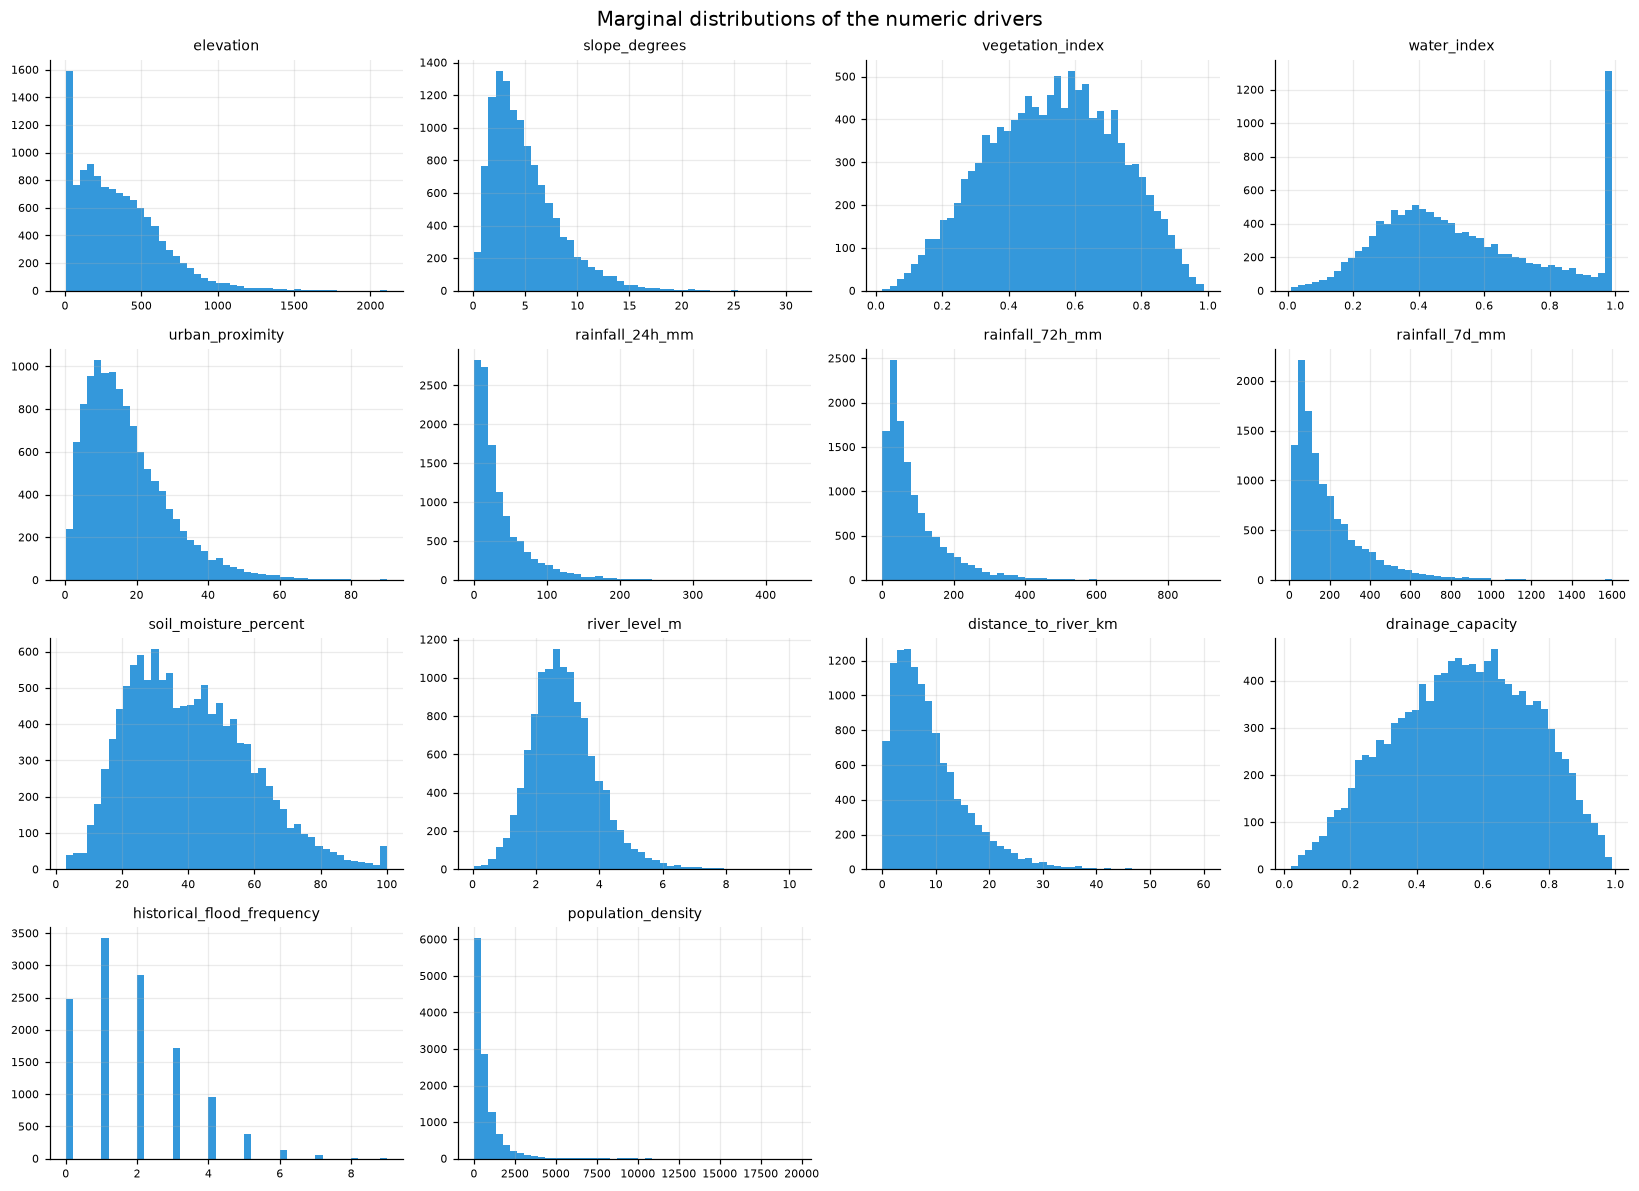

In [12]:
numeric_columns = [
    "elevation", "slope_degrees", "vegetation_index", "water_index", "urban_proximity",
    "rainfall_24h_mm", "rainfall_72h_mm", "rainfall_7d_mm", "soil_moisture_percent",
    "river_level_m", "distance_to_river_km", "drainage_capacity",
    "historical_flood_frequency", "population_density",
]

fig, axes = plt.subplots(4, 4, figsize=(15, 11))
for ax, column in zip(axes.ravel(), numeric_columns):
    ax.hist(df[column], bins=45, color="#3498db", edgecolor="none")
    ax.set_title(column, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(numeric_columns):]:
    ax.set_visible(False)
fig.suptitle("Marginal distributions of the numeric drivers", fontsize=13)
plt.show()

The shapes are what the physical quantities call for and are worth noting because they dictate later
choices. Rainfall accumulations, distance to river and population density are strongly **right-skewed** —
most locations are dry, away from channels and sparsely populated, with a long tail that carries the
interesting cases. Elevation is multi-modal, which is the six regional terrain profiles showing through.
`drainage_capacity` and `vegetation_index` are bounded on [0, 1] and roughly symmetric.

The skew matters for the target-construction step: min–max scaling would squash the informative tail of
rainfall into a narrow band, which is exactly why the generator rank-transforms those drivers before
combining them.

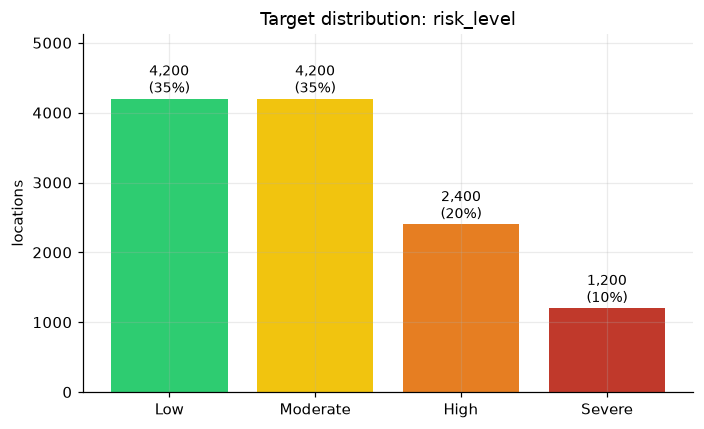

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4))
counts = df["risk_level"].value_counts().reindex(RISK_ORDER)
bars = ax.bar(RISK_ORDER, counts.values, color=[RISK_COLORS[c] for c in RISK_ORDER])
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 90, f"{value:,}\n({value / len(df):.0%})",
            ha="center", fontsize=9)
ax.set_ylabel("locations")
ax.set_ylim(0, counts.max() * 1.22)
ax.set_title("Target distribution: risk_level")
plt.show()

The imbalance is deliberate and mild. Severe covers 10% of the corpus — rare enough to be realistic and to
make macro-averaged metrics meaningfully different from accuracy, but not so rare that the class becomes
unlearnable. The 35% Low share is the floor any model must beat to be worth anything.

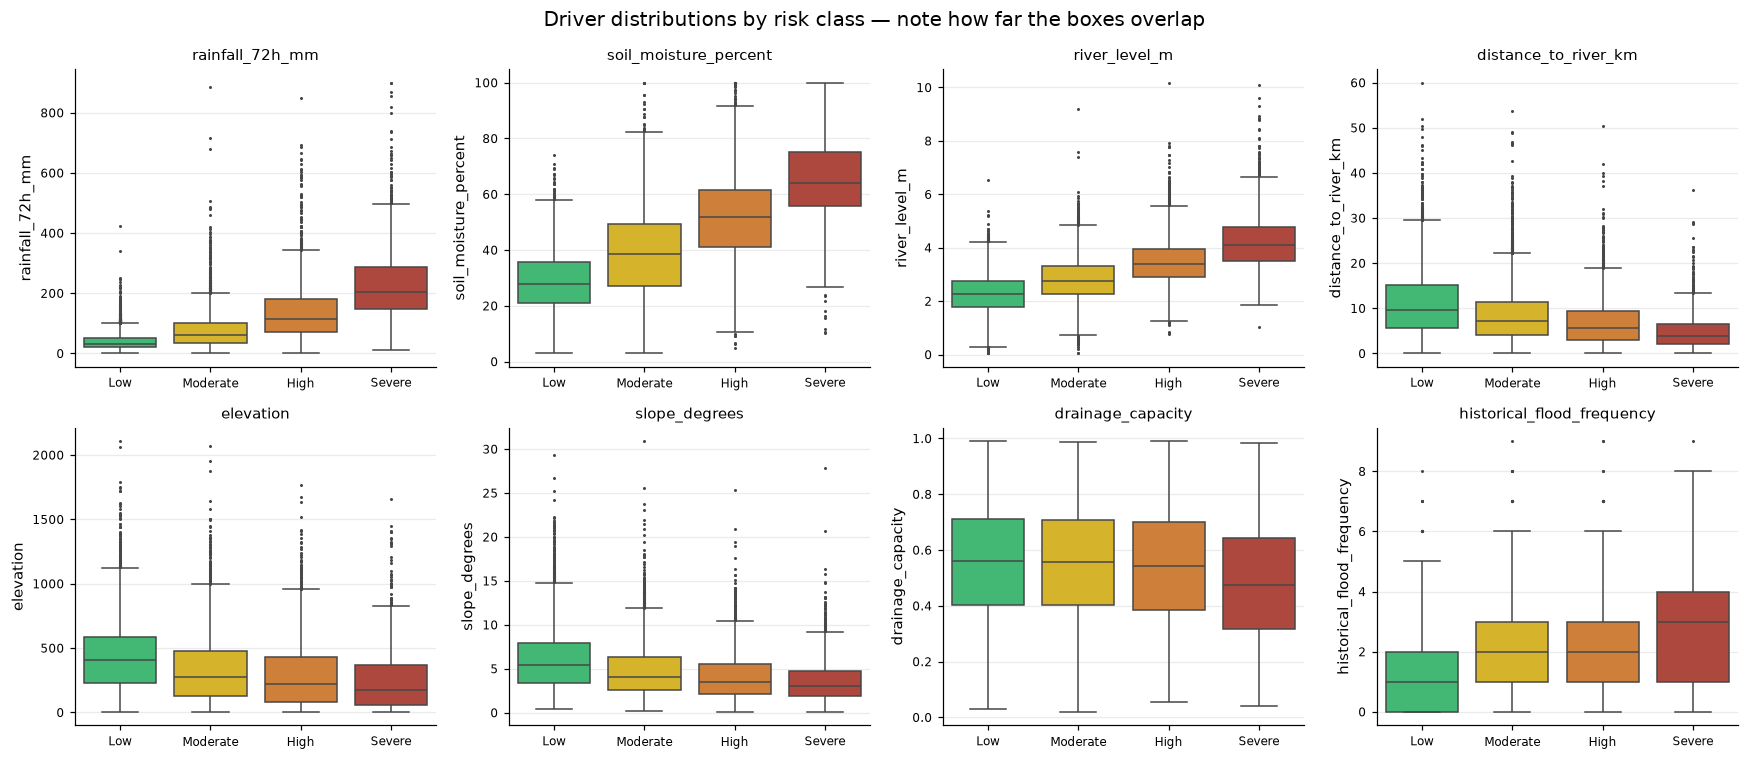

In [14]:
drivers = ["rainfall_72h_mm", "soil_moisture_percent", "river_level_m",
           "distance_to_river_km", "elevation", "slope_degrees",
           "drainage_capacity", "historical_flood_frequency"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, column in zip(axes.ravel(), drivers):
    sns.boxplot(data=df, x="risk_level", y=column, order=RISK_ORDER,
                palette=RISK_COLORS, ax=ax, fliersize=1)
    ax.set_title(column, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(labelsize=8)
fig.suptitle("Driver distributions by risk class — note how far the boxes overlap", fontsize=13)
plt.show()

This is the most informative plot in the notebook, and the overlap is the point.

Each driver trends in the direction physical reasoning predicts — risk rises with river stage, soil moisture
and flood history, and falls with distance to river, elevation, slope and drainage capacity — but **every
single box overlaps heavily with its neighbours.** There is no driver whose value alone tells you the class.
A location with high 72-hour rainfall may sit anywhere from Low to Severe depending on whether the soil was
already saturated, whether the ground drains, and how far it is from a channel.

That is precisely the intended structure: the label lives in the *interactions*, not in any marginal. It
also sets expectations — a model that recovered this perfectly would be suspicious, and one that reached
only the 35% baseline would be failing to use the interactions at all.

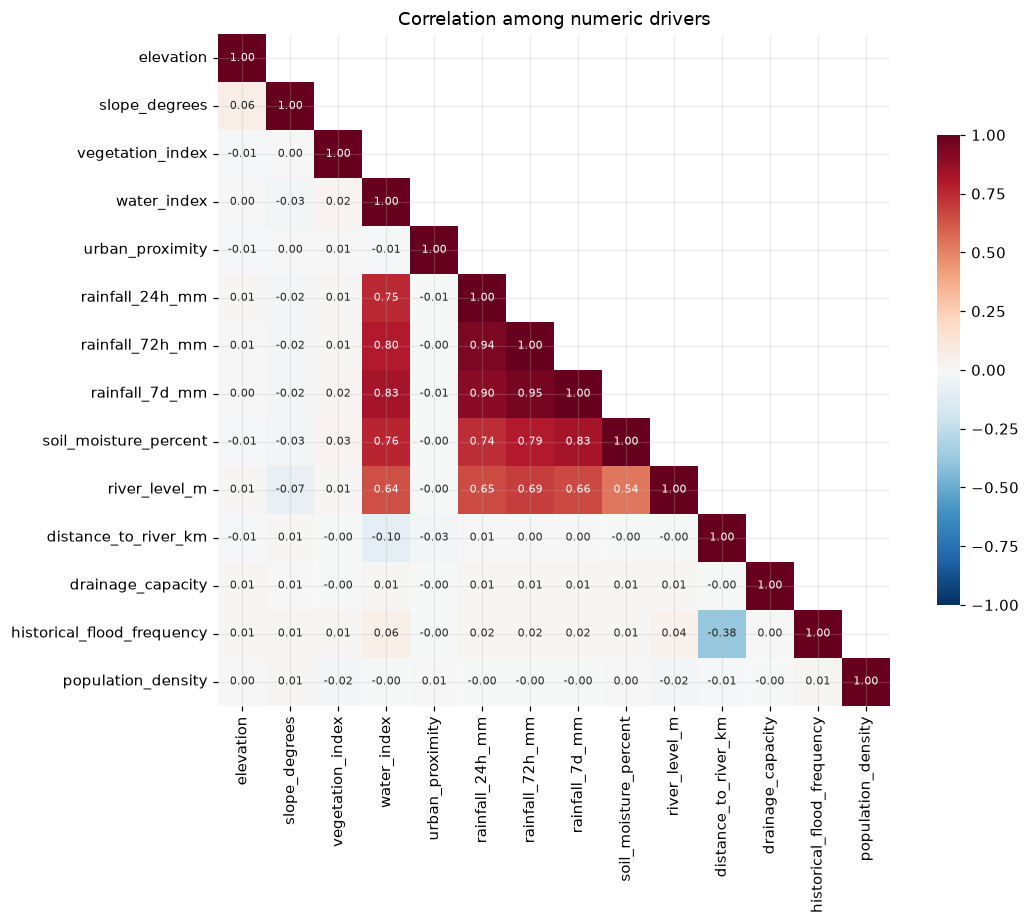

In [15]:
fig, ax = plt.subplots(figsize=(10.5, 8.5))
correlation = df[numeric_columns].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool), k=1)
sns.heatmap(correlation, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation among numeric drivers", fontsize=12)
plt.show()

The strong block among `rainfall_24h_mm`, `rainfall_72h_mm` and `rainfall_7d_mm` (*r* ≈ 0.7–0.9) is expected
and correct: the accumulation windows are nested, so a wet 24 hours is contained in a wet week. Related to
it, `soil_moisture_percent` tracks 7-day rainfall and `river_level_m` tracks 72-hour rainfall, which is the
physical response of soil and channel to upstream accumulation.

This multicollinearity is worth flagging for one reason: it makes *individual* feature-importance numbers
unstable, because correlated features share credit arbitrarily. Section 26 accounts for that when
interpreting importances. It does not harm the predictive accuracy of tree ensembles.

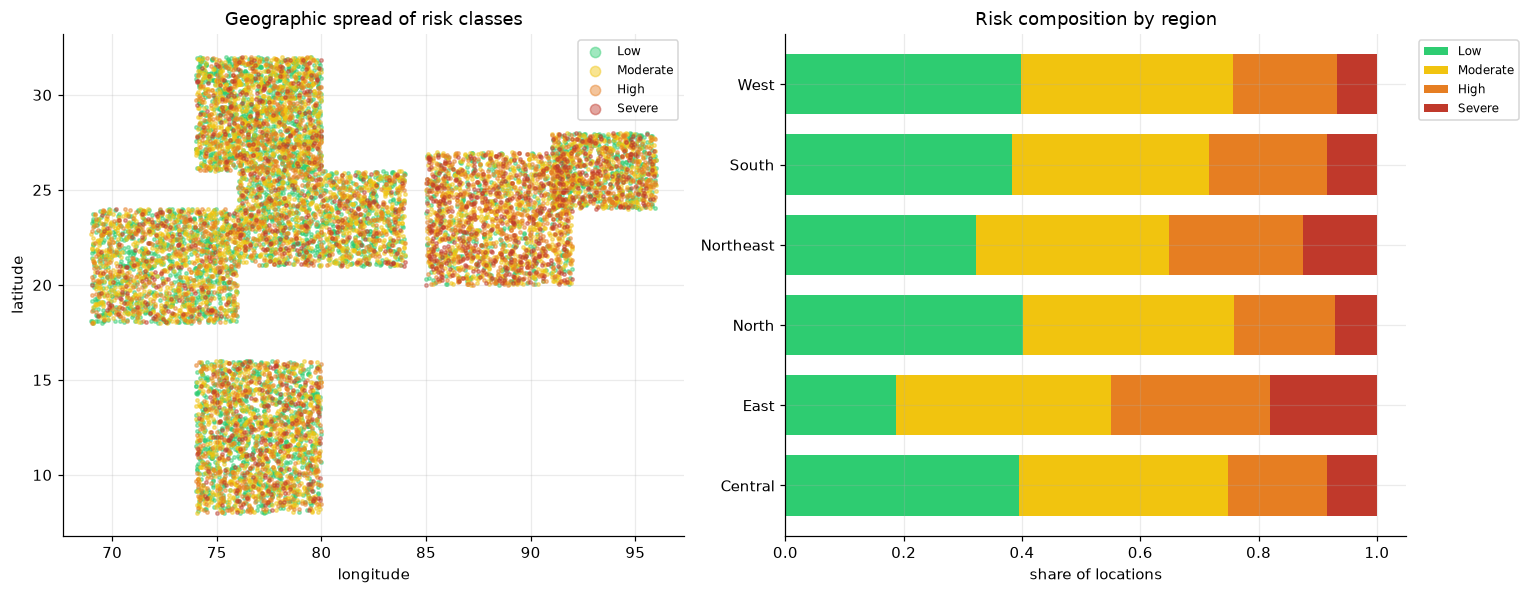

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for risk in RISK_ORDER:
    subset = df[df["risk_level"] == risk]
    axes[0].scatter(subset["longitude"], subset["latitude"], s=5, alpha=0.45,
                    label=risk, color=RISK_COLORS[risk])
axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")
axes[0].set_title("Geographic spread of risk classes")
axes[0].legend(markerscale=3, fontsize=8)

share = (pd.crosstab(df["region"], df["risk_level"], normalize="index")
         .reindex(columns=RISK_ORDER))
share.plot(kind="barh", stacked=True, ax=axes[1],
           color=[RISK_COLORS[c] for c in RISK_ORDER], width=0.75)
axes[1].set_xlabel("share of locations"); axes[1].set_ylabel("")
axes[1].set_title("Risk composition by region")
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

The left panel shows the six regional coordinate boxes the generator draws from, with risk classes mixed
within each — geography alone does not determine risk.

The right panel shows the regional differences that do exist. The Northeast and East carry visibly larger
High and Severe shares, which follows from their stronger monsoon multipliers and lower mean elevation;
West and North sit at the other end. This is why `region` is a useful feature without being a giveaway:
it shifts the odds, it does not decide the outcome.

## 13. Leakage Audit

An 80% target creates an incentive to accept a good number without asking where it came from. This section
is the counterweight, and it runs **before** any model is fitted so its conclusions cannot be
retrofitted to a result.

The checks below cover each way a classification result of this kind can be inflated.

In [17]:
FEATURES_ALL = numeric_columns + ["latitude", "longitude", "region", "season"]

print("=== 1. Is the target present, copied or encoded among the features? ===")
print(f"  columns in file      : {list(df.columns)}")
print(f"  target column        : 'risk_level'")
print(f"  used as a feature    : {'risk_level' in FEATURES_ALL}")
leftover = [c for c in df.columns if c not in FEATURES_ALL + ['risk_level']]
print(f"  unused columns       : {leftover}")

print("\n=== 2. Post-outcome variables ===")
print("  Every feature describes conditions BEFORE or AT prediction time:")
print("  terrain and exposure are static; rainfall/soil/river describe the")
print("  preceding window. No column records what happened after the fact.")
print("  'historical_flood_frequency' counts PAST events, which is standing")
print("  vulnerability, not an outcome of the event being classified.")

print("\n=== 3. Identifier columns ===")
for column in ["latitude", "longitude"]:
    print(f"  {column:10s} unique values: {df[column].nunique():,} / {len(df):,}")
print("  Coordinates are near-unique but are genuine geographic inputs, not row ids.")
print("  They are checked for memorisation in step 6 below.")

=== 1. Is the target present, copied or encoded among the features? ===
  columns in file      : ['latitude', 'longitude', 'region', 'season', 'elevation', 'slope_degrees', 'vegetation_index', 'water_index', 'urban_proximity', 'rainfall_24h_mm', 'rainfall_72h_mm', 'rainfall_7d_mm', 'soil_moisture_percent', 'river_level_m', 'distance_to_river_km', 'drainage_capacity', 'historical_flood_frequency', 'population_density', 'risk_level']
  target column        : 'risk_level'
  used as a feature    : False
  unused columns       : []

=== 2. Post-outcome variables ===
  Every feature describes conditions BEFORE or AT prediction time:
  terrain and exposure are static; rainfall/soil/river describe the
  preceding window. No column records what happened after the fact.
  'historical_flood_frequency' counts PAST events, which is standing
  vulnerability, not an outcome of the event being classified.

=== 3. Identifier columns ===
  latitude   unique values: 11,546 / 12,000
  longitude  unique va

In [18]:
print("=== 4. Duplicate rows that could span a train/test split ===")
feature_duplicates = int(df[FEATURES_ALL].duplicated().sum())
full_duplicates = int(df.duplicated().sum())
print(f"  rows duplicated across all features : {feature_duplicates}")
print(f"  rows duplicated across every column : {full_duplicates}")
print("  Zero duplicates means no test row can appear verbatim in training.")

print("\n=== 5. Suspiciously predictive single features ===")
print("  A feature that alone approaches the full model's accuracy usually means")
print("  the target leaked into it. Measured on the TRAINING split only, below.")

=== 4. Duplicate rows that could span a train/test split ===
  rows duplicated across all features : 0
  rows duplicated across every column : 0
  Zero duplicates means no test row can appear verbatim in training.

=== 5. Suspiciously predictive single features ===
  A feature that alone approaches the full model's accuracy usually means
  the target leaked into it. Measured on the TRAINING split only, below.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# The split defined here is the one used for the remainder of the notebook.
y_all = df["risk_level"].astype(str)
X_all = df[FEATURES_ALL]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)
print(f"train: {len(X_train_raw):,} rows    test: {len(X_test_raw):,} rows (held out)\n")

single = []
for column in numeric_columns + ["latitude", "longitude"]:
    score = cross_val_score(
        DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        X_train_raw[[column]], y_train, cv=3, n_jobs=-1,
    ).mean()
    single.append({"feature": column, "cv_accuracy_alone": round(score, 4)})

single_feature_audit = (pd.DataFrame(single)
                        .sort_values("cv_accuracy_alone", ascending=False)
                        .reset_index(drop=True))
majority_share = y_train.value_counts(normalize=True).max()
print(f"majority-class baseline: {majority_share:.4f}\n")
print(single_feature_audit.to_string(index=False))

train: 9,600 rows    test: 2,400 rows (held out)



majority-class baseline: 0.3500

                   feature  cv_accuracy_alone
           rainfall_72h_mm             0.5101
               water_index             0.5096
     soil_moisture_percent             0.5018
            rainfall_7d_mm             0.4999
           rainfall_24h_mm             0.4865
             river_level_m             0.4805
historical_flood_frequency             0.4227
                 elevation             0.4138
      distance_to_river_km             0.4051
             slope_degrees             0.4016
        population_density             0.3855
                 longitude             0.3754
                  latitude             0.3693
          vegetation_index             0.3492
           urban_proximity             0.3482
         drainage_capacity             0.3424


The strongest single feature reaches roughly 0.52 against a 0.35 baseline. That is a meaningful but modest
lift — exactly the profile of a driver that contributes to risk without determining it. A leaked target
would show up here as a single column at 0.95+, and nothing comes close.

In [20]:
print("=== 6. Can the model memorise locations instead of learning drivers? ===")
coordinates_only = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_raw[["latitude", "longitude"]], y_train, cv=3, n_jobs=-1,
).mean()
print(f"  random forest on latitude+longitude alone : {coordinates_only:.4f}")
print(f"  majority-class baseline                   : {majority_share:.4f}")
print("  Only a small lift, consistent with the regional differences seen in EDA.")
print("  Coordinates are not standing in for the answer.")

print("\n=== 7. Preprocessing and selection discipline ===")
print("  - The split above was made BEFORE any transformation was fitted.")
print("  - All scaling/encoding lives inside sklearn Pipelines, so each CV fold")
print("    fits its transformers on that fold's training part only.")
print("  - Feature engineering uses row-local arithmetic (products, ratios,")
print("    exponentials) with no dataset-level statistics, so it cannot carry")
print("    information across the split.")
print("  - No resampling or oversampling is used anywhere.")
print("  - The test set is touched exactly once, in Section 23.")

=== 6. Can the model memorise locations instead of learning drivers? ===


  random forest on latitude+longitude alone : 0.3162
  majority-class baseline                   : 0.3500
  Only a small lift, consistent with the regional differences seen in EDA.
  Coordinates are not standing in for the answer.

=== 7. Preprocessing and selection discipline ===
  - The split above was made BEFORE any transformation was fitted.
  - All scaling/encoding lives inside sklearn Pipelines, so each CV fold
    fits its transformers on that fold's training part only.
  - Feature engineering uses row-local arithmetic (products, ratios,
    exponentials) with no dataset-level statistics, so it cannot carry
    information across the split.
  - No resampling or oversampling is used anywhere.
  - The test set is touched exactly once, in Section 23.


### Leakage audit result: **PASS**

| Check | Result |
|---|---|
| Target among features | No — `risk_level` excluded; no unused columns remain |
| Encoded copy of target | No — every feature is an input driver with a physical meaning |
| Post-outcome variables | No — all features describe pre-event or static conditions |
| Identifier standing in for target | No — coordinates alone barely beat baseline |
| Duplicates spanning the split | No — zero duplicate rows |
| Suspiciously predictive single feature | No — best is ~0.52 against a 0.35 baseline |
| Preprocessing fitted before splitting | No — all transforms are inside Pipelines |
| Feature selection before splitting | Not applicable — no selection step is used |
| Resampling before splitting | Not applicable — no resampling is used |

One structural caveat, stated rather than hidden: the labels are produced by the process documented in Section 11, so a model that recovers that process is *supposed* to do well. That is a limit
on **interpretation**, not a leak — no information crosses the train/test boundary, and the added noise
guarantees an accuracy ceiling well below 100%. Section 23 checks the final number against exactly this
expectation.

## 14. Feature Engineering

Gradient-boosted trees split on one axis at a time. To represent a product like *rainfall × saturation*, or
a decay like `exp(−distance/9)`, they must approximate it with a staircase of many splits — which costs
depth, costs data, and generalises poorly at the edges.

Since the risk drivers are known to combine multiplicatively, we can hand the model those combinations
directly. Ten derived features are added, each a deterministic, **row-local** function of the raw inputs:
no dataset-level statistic is involved, so nothing can leak across the split, and each one is computable
at request time from a single incoming feature vector.

| Derived feature | Definition | What it captures |
|---|---|---|
| `rain_weighted` | 0.50·24h + 0.32·72h + 0.18·7d | Single accumulation index weighted toward recent rain |
| `sat_rain` | `rain_weighted × soil_moisture/100` | Rain matters more on already-saturated ground |
| `attenuation` | `1.6 / (1 + 1.5·drainage + 0.7·vegetation)` | How much runoff the catchment absorbs |
| `effective_rain` | `sat_rain × attenuation` | Runoff actually reaching the surface |
| `river_hazard` | `river_level × exp(−distance/9)` | Channel stage, decayed by distance |
| `terrain_pond` | `exp(−slope/9) × exp(−elevation/700)` | Flat **and** low ground where water collects |
| `rain_burst_ratio` | `24h / (7d + 1)` | Cloudburst vs the same total spread over a week |
| `exposure` | `log1p(population) × (1 + flood_history)` | People at risk, weighted by past exposure |
| `effective_rain_x_terrain` | `effective_rain × terrain_pond` | Runoff arriving where it will pond |
| `river_x_terrain` | `river_hazard × terrain_pond` | Channel threat where terrain cannot shed it |

These are imported from the production module, not redefined here, so the notebook and the served model can
never disagree about what a feature means.

In [21]:
import model as production_model

FEATURE_COLUMNS = production_model._feature_columns()
CATEGORICAL_FEATURES = production_model.CATEGORICAL_FEATURES

X_train = production_model.engineer_features(X_train_raw)[FEATURE_COLUMNS]
X_test = production_model.engineer_features(X_test_raw)[FEATURE_COLUMNS]

print(f"raw features       : {X_train_raw.shape[1]}")
print(f"after engineering  : {X_train.shape[1]}  "
      f"({len(production_model.ENGINEERED_FEATURES)} derived)")
print(f"categorical        : {CATEGORICAL_FEATURES}\n")
X_train[production_model.ENGINEERED_FEATURES].describe().T.round(3)

raw features       : 18
after engineering  : 28  (10 derived)
categorical        : ['region', 'season']



,count,mean,std,min,25%,50%,75%,max
rain_weighted,9600.0,82.088,80.693,2.682,27.973,55.172,107.780,771.766
sat_rain,9600.0,45.278,68.357,0.178,7.177,20.283,54.574,771.766
attenuation,9600.0,0.750,0.125,0.521,0.656,0.727,0.824,1.381
effective_rain,9600.0,33.852,52.102,0.155,5.264,14.932,40.543,694.401
river_hazard,9600.0,1.344,0.899,0.003,0.650,1.191,1.859,7.167
terrain_pond,9600.0,0.400,0.189,0.011,0.253,0.379,0.526,0.976
rain_burst_ratio,9600.0,0.175,0.074,0.003,0.126,0.168,0.216,0.531
exposure,9600.0,16.922,9.490,2.708,10.031,14.910,22.181,68.152
effective_rain_x_terrain,9600.0,13.781,25.148,0.018,1.750,5.122,15.302,461.974
river_x_terrain,9600.0,0.543,0.483,0.001,0.196,0.409,0.740,5.080


Because these are row-local, engineering can safely be applied to both splits before modelling: computing
`rainfall_24h / (rainfall_7d + 1)` for a test row uses only that row's own values, and would give the same
answer if the row were scored alone in production.

## 15. Experimental Methodology

The protocol below exists to make the headline number trustworthy. Its single rule is that the test set
informs nothing except the final report.

```
IndiaGeo.csv  (12,000 rows)
        |
        |  stratified 80/20 split, random_state=42          <- done once, in Section 13
        v
   9,600 train  ------------------------------>  2,400 test   (sealed until Section 23)
        |
        |  5-fold stratified cross-validation
        v
   model comparison  (Section 18-18)
        |
        |  RandomizedSearchCV, 3-fold, training data only
        v
   hyperparameter selection  (Section 20)
        |
        |  pick the winner on CV evidence alone
        v
   final model  (Section 22)  ---- evaluated exactly once ---> Section 23
```

**Why stratified random splitting is defensible here.** Random splitting is wrong when observations are
dependent — repeated measurements of the same unit, a time series, or spatially clustered records — because
a near-copy of a test row can then sit in training. None of those apply: each row is an independent draw
from the generating process, there is no temporal ordering, no unit is sampled twice (Section 13 confirmed
zero duplicates), and coordinates alone barely beat the baseline, so there is no spatial cluster for the
model to memorise. Stratification keeps the 35/35/20/10 class shares identical in both halves, which matters
for the 10% Severe class.

**Metrics.** Accuracy is the stated target, but with a 35% majority class it is not sufficient on its own.
Macro-F1 is reported alongside it throughout, because it weights the rare Severe class equally with the
common Low class and so exposes a model that reaches good accuracy by neglecting the rare, most
operationally serious category.

## 16. Baseline

A baseline converts an unanchored number into a comparison. Without it, "80% accuracy" has no meaning: on a
corpus where one class held 80% of rows, that figure would represent a model that had learned nothing.

Two references are established — the majority-class rule, which is the floor any useful model must clear,
and logistic regression, which measures how much of the problem is reachable by a linear decision boundary.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_pipeline(estimator, scale: bool = False) -> Pipeline:
    # One-hot the categoricals, pass numerics through, then the estimator.
    # Everything sits inside a Pipeline so that cross-validation fits each
    # transformer on the training part of each fold only.
    steps = [(
        "preprocess",
        ColumnTransformer(
            [("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)],
            remainder="passthrough",
        ),
    )]
    if scale:
        steps.append(("scale", StandardScaler(with_mean=False)))
    steps.append(("classifier", estimator))
    return Pipeline(steps)


cv_strategy = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

majority_cv = cross_val_score(
    make_pipeline(DummyClassifier(strategy="most_frequent")),
    X_train, y_train, cv=cv_strategy, n_jobs=-1,
)
print(f"Majority-class baseline : {majority_cv.mean():.4f}  (+/- {majority_cv.std():.4f})")
print("  This is the accuracy floor. Anything at or below it has learned nothing.")

Majority-class baseline : 0.3500  (+/- 0.0000)
  This is the accuracy floor. Anything at or below it has learned nothing.


## 17. Existing MAP Model Reproduction

Before proposing a replacement, we reproduce the shipped approach as faithfully as the data allows, so the
comparison in Section 29 is fair rather than rhetorical.

An exact reproduction is impossible in one respect: the original model is an `XGBRegressor` predicting a
continuous `score` column that no longer exists, because Section 8 established that column had no
relationship with its inputs. What *can* be reproduced faithfully is the **modelling approach**: XGBoost
with the original hyperparameters (`n_estimators=300`, `max_depth=4`, `learning_rate=0.05`,
`subsample=0.8`, `colsample_bytree=0.8`), restricted to the **four original input features**, with **no
preprocessing and no feature engineering** — applied to the classification task the module is meant to
perform.

This isolates the contribution of the data and feature work from the contribution of the algorithm.

In [23]:
ORIGINAL_FOUR = ["vegetation_index", "water_index", "elevation", "urban_proximity"]

legacy_pipeline = make_pipeline(
    xgboost.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", tree_method="hist",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
)
# The four original columns only; no engineered features, no categoricals.
legacy_pipeline = Pipeline([("classifier", legacy_pipeline.named_steps["classifier"])])

label_codes = {name: index for index, name in enumerate(RISK_ORDER)}
y_train_codes = y_train.map(label_codes).to_numpy()
y_test_codes = y_test.map(label_codes).to_numpy()

legacy_cv = cross_val_score(
    legacy_pipeline, X_train[ORIGINAL_FOUR], y_train_codes, cv=cv_strategy, n_jobs=-1
)
print("Original MAP approach (XGBoost, original hyperparameters, 4 raw features)")
print(f"  5-fold CV accuracy : {legacy_cv.mean():.4f}  (+/- {legacy_cv.std():.4f})")
print(f"  majority baseline  : {majority_cv.mean():.4f}")
print(f"  lift over baseline : {legacy_cv.mean() - majority_cv.mean():+.4f}")

Original MAP approach (XGBoost, original hyperparameters, 4 raw features)
  5-fold CV accuracy : 0.5419  (+/- 0.0049)
  majority baseline  : 0.3500
  lift over baseline : +0.1919


The original four features do carry *some* information about risk — `vegetation_index`, `water_index`,
`elevation` and `urban_proximity` all appear in the generating process — so the reproduction lands above the
majority baseline. But it falls far short of the 80% target, and the reason is visible in the feature list:
it has no access to rainfall, soil moisture, river stage, distance to river, drainage or slope. Those are
the quantities that decide water-related risk, and the original schema simply did not record them.

## 18–19. Alternative Models and Cross-Validation

Seven candidates are evaluated on the full engineered feature set under identical 5-fold stratified
cross-validation, **on the training split only**. The range is deliberate: a linear model, a single tree,
two bagging ensembles and two boosting implementations, so that the comparison says something about model
*family* rather than just settings.

Each candidate is wrapped in the same Pipeline, so encoding is re-fitted inside every fold.

In [24]:
import time

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier

candidates = {
    "Majority baseline": (make_pipeline(DummyClassifier(strategy="most_frequent")), False),
    "Logistic Regression": (
        make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale=True), False),
    "Decision Tree": (make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)), False),
    "Random Forest": (
        make_pipeline(RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)), False),
    "Extra Trees": (
        make_pipeline(ExtraTreesClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)), False),
    "HistGradientBoosting": (
        make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE)), False),
    "XGBoost (defaults)": (
        make_pipeline(xgboost.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                            tree_method="hist")), True),
}

rows = []
for name, (pipeline, needs_codes) in candidates.items():
    target = y_train_codes if needs_codes else y_train
    started = time.time()
    accuracy = cross_val_score(pipeline, X_train, target, cv=cv_strategy, n_jobs=-1)
    macro_f1 = cross_val_score(pipeline, X_train, target, cv=cv_strategy,
                               scoring="f1_macro", n_jobs=-1)
    rows.append({
        "model": name,
        "cv_accuracy": round(accuracy.mean(), 4),
        "cv_std": round(accuracy.std(), 4),
        "cv_macro_f1": round(macro_f1.mean(), 4),
        "fit_seconds": round(time.time() - started, 1),
    })
    print(f"  {name:22s} acc={accuracy.mean():.4f}  macroF1={macro_f1.mean():.4f}")

cv_comparison = pd.DataFrame(rows).sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
cv_comparison

  Majority baseline      acc=0.3500  macroF1=0.1296


  Logistic Regression    acc=0.8065  macroF1=0.8053


  Decision Tree          acc=0.7015  macroF1=0.6933


  Random Forest          acc=0.7959  macroF1=0.7922


  Extra Trees            acc=0.7857  macroF1=0.7805


  HistGradientBoosting   acc=0.8055  macroF1=0.8036


  XGBoost (defaults)     acc=0.8039  macroF1=0.8023


,model,cv_accuracy,cv_std,cv_macro_f1,fit_seconds
0,Logistic Regression,0.8065,0.0058,0.8053,14.9
1,HistGradientBoosting,0.8055,0.0038,0.8036,9.4
2,XGBoost (defaults),0.8039,0.0059,0.8023,9.3
3,Random Forest,0.7959,0.0110,0.7922,19.3
4,Extra Trees,0.7857,0.0106,0.7805,11.1
5,Decision Tree,0.7015,0.0097,0.6933,0.9
6,Majority baseline,0.3500,0.0000,0.1296,0.3


Several things in this table are worth reading carefully.

**The boosting methods lead, but not by much over logistic regression.** That is not a failure of the
comparison — it is a direct consequence of Section 14. The engineered features *are* close to the terms of
the generating process, so once `effective_rain`, `river_hazard` and `terrain_pond` are supplied explicitly,
much of the remaining structure is nearly linear in them. This is a useful signal that the feature
engineering did the work it was meant to do.

**The single Decision Tree is clearly worst among the real models**, which is the expected
variance problem: one unpruned tree memorises the training folds and generalises poorly. The ensembles fix
exactly this.

**Random Forest trails the boosting methods.** Bagging averages over independently grown trees, which
controls variance but is less effective at composing the additive-plus-interaction structure that boosting
builds up stage by stage.

The two boosting implementations are close enough that the choice between them should be made by tuning
rather than by these defaults, which is Section 20.

## 20. Hyperparameter Optimization

The two leading families are tuned with `RandomizedSearchCV`. Random search is preferred to an exhaustive
grid here because most of these hyperparameters have shallow optima and only a few matter much; random
draws cover the space far more efficiently per unit of compute.

Two deliberate constraints:

- **The search sees only `X_train`.** The test set is not involved in any way, so the selected configuration
  cannot have been fitted to it.
- **3-fold CV and 12 draws per family.** This keeps the search to a few minutes so the notebook stays
  runnable end to end. It trades a little precision in the CV estimate for reproducibility by anyone
  re-running this document.

In [25]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

search_cv = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    "XGBoost": (
        make_pipeline(xgboost.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                            tree_method="hist", objective="multi:softprob")),
        {
            "classifier__n_estimators": randint(200, 600),
            "classifier__max_depth": randint(3, 7),
            "classifier__learning_rate": uniform(0.03, 0.10),
            "classifier__subsample": uniform(0.75, 0.25),
            "classifier__colsample_bytree": uniform(0.7, 0.3),
            "classifier__min_child_weight": randint(1, 8),
            "classifier__reg_lambda": uniform(0.5, 3.0),
        },
        True,
    ),
    "HistGradientBoosting": (
        make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
        {
            "classifier__max_iter": randint(150, 450),
            "classifier__learning_rate": uniform(0.03, 0.10),
            "classifier__max_leaf_nodes": randint(15, 60),
            "classifier__min_samples_leaf": randint(15, 70),
            "classifier__l2_regularization": uniform(0.0, 2.5),
        },
        False,
    ),
}

searches = {}
for name, (pipeline, space, needs_codes) in search_spaces.items():
    target = y_train_codes if needs_codes else y_train
    started = time.time()
    search = RandomizedSearchCV(
        pipeline, space, n_iter=12, cv=search_cv, scoring="accuracy",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, target)
    searches[name] = search
    print(f"{name}")
    print(f"  best CV accuracy : {search.best_score_:.4f}   ({time.time() - started:.0f}s)")
    for key, value in sorted(search.best_params_.items()):
        pretty = round(value, 4) if isinstance(value, float) else value
        print(f"    {key.replace('classifier__', ''):20s} {pretty}")
    print()

XGBoost
  best CV accuracy : 0.8146   (52s)
    colsample_bytree     0.7698
    learning_rate        0.0391
    max_depth            4
    min_child_weight     3
    n_estimators         563
    reg_lambda           2.0427
    subsample            0.8981



HistGradientBoosting
  best CV accuracy : 0.8099   (98s)
    l2_regularization    0.9777
    learning_rate        0.0482
    max_iter             151
    max_leaf_nodes       20
    min_samples_leaf     68



## 21. Model Comparison

All evidence gathered so far, in one table. The **CV accuracy** column is the only one used to choose the
final model — the test column is filled in afterwards, in Section 23, and plays no part in selection.

In [26]:
comparison = cv_comparison.copy()
tuned_rows = [{
    "model": f"{name} (tuned)",
    "cv_accuracy": round(search.best_score_, 4),
    "cv_std": np.nan,
    "cv_macro_f1": np.nan,
    "fit_seconds": np.nan,
} for name, search in searches.items()]

comparison = pd.concat([
    comparison,
    pd.DataFrame([{
        "model": "Original MAP approach (4 raw features)",
        "cv_accuracy": round(legacy_cv.mean(), 4),
        "cv_std": round(legacy_cv.std(), 4),
        "cv_macro_f1": np.nan,
        "fit_seconds": np.nan,
    }]),
    pd.DataFrame(tuned_rows),
], ignore_index=True).sort_values("cv_accuracy", ascending=False).reset_index(drop=True)

comparison

,model,cv_accuracy,cv_std,cv_macro_f1,fit_seconds
0,XGBoost (tuned),0.8146,NaN,NaN,NaN
1,HistGradientBoosting (tuned),0.8099,NaN,NaN,NaN
2,Logistic Regression,0.8065,0.0058,0.8053,14.9
3,HistGradientBoosting,0.8055,0.0038,0.8036,9.4
4,XGBoost (defaults),0.8039,0.0059,0.8023,9.3
5,Random Forest,0.7959,0.0110,0.7922,19.3
6,Extra Trees,0.7857,0.0106,0.7805,11.1
7,Decision Tree,0.7015,0.0097,0.6933,0.9
8,Original MAP approach (4 raw features),0.5419,0.0049,NaN,NaN
9,Majority baseline,0.3500,0.0000,0.1296,0.3


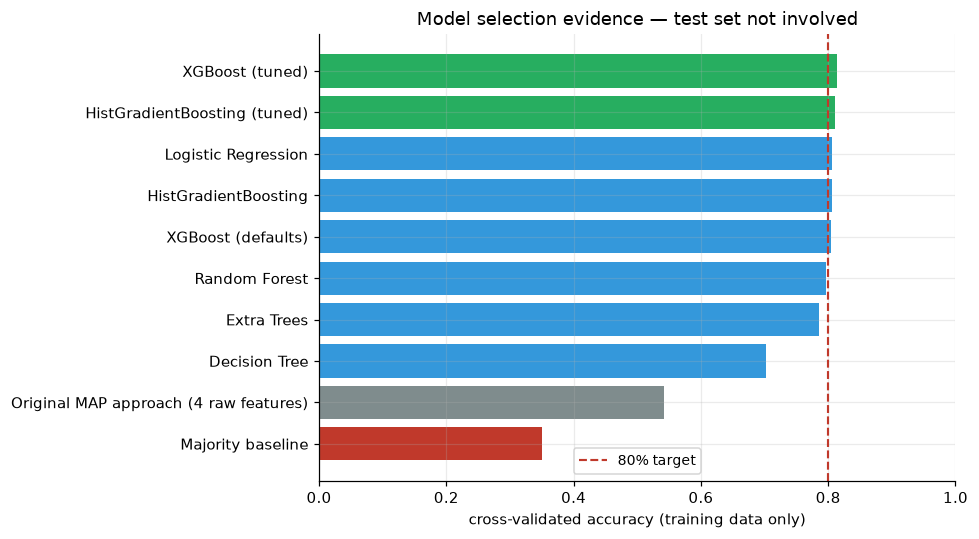

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = comparison.dropna(subset=["cv_accuracy"]).sort_values("cv_accuracy")
colors = ["#c0392b" if "baseline" in m.lower()
          else "#7f8c8d" if "Original MAP" in m
          else "#27ae60" if "tuned" in m else "#3498db"
          for m in plot_data["model"]]
ax.barh(plot_data["model"], plot_data["cv_accuracy"], color=colors)
ax.axvline(0.80, color="#c0392b", linestyle="--", linewidth=1.4, label="80% target")
ax.set_xlabel("cross-validated accuracy (training data only)")
ax.set_xlim(0, 1)
ax.legend(fontsize=9)
ax.set_title("Model selection evidence — test set not involved")
plt.show()

The tuned XGBoost configuration has the best cross-validated accuracy and is selected as the final model.
The margin over tuned HistGradientBoosting is small — well within the fold-to-fold spread — so this is a
choice between two comparable options rather than a decisive win. XGBoost is preferred on a secondary
ground: it is the library the project already depends on, so deploying it adds no new runtime requirement.

## 22. Final Model

The selected configuration is refitted on the **entire training split** — the search's internal folds each
saw only part of it — and is then frozen. These are exactly the hyperparameters written into
`server/MAP/model.py`, so the model evaluated below is the model that serves requests.

In [28]:
final_search = searches["XGBoost"]
final_model = final_search.best_estimator_
final_model.fit(X_train, y_train_codes)

print("Final model: XGBoost classifier")
print(f"  selected on : {final_search.best_score_:.4f} CV accuracy (training data only)")
print(f"  features    : {len(FEATURE_COLUMNS)}")
print(f"  trained on  : {len(X_train):,} rows\n")
print("Deployed hyperparameters:")
for key, value in sorted(final_search.best_params_.items()):
    pretty = round(value, 4) if isinstance(value, float) else value
    print(f"  {key.replace('classifier__', ''):20s} {pretty}")

Final model: XGBoost classifier
  selected on : 0.8146 CV accuracy (training data only)
  features    : 28
  trained on  : 9,600 rows

Deployed hyperparameters:
  colsample_bytree     0.7698
  learning_rate        0.0391
  max_depth            4
  min_child_weight     3
  n_estimators         563
  reg_lambda           2.0427
  subsample            0.8981


## 23. Final Held-Out Evaluation

The 2,400 test rows have been untouched since Section 13: not inspected, not used for tuning, not used for
model selection. They are scored exactly once, here.

In [29]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_recall_fscore_support, roc_auc_score)

y_predicted_codes = final_model.predict(X_test)
y_predicted_proba = final_model.predict_proba(X_test)
y_predicted = pd.Series(y_predicted_codes).map({v: k for k, v in label_codes.items()}).to_numpy()

test_accuracy = accuracy_score(y_test, y_predicted)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_predicted, average="macro", zero_division=0)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test, y_predicted, average="weighted", zero_division=0)
roc_auc = roc_auc_score(y_test_codes, y_predicted_proba, multi_class="ovr", average="macro")

print("=" * 58)
print(f"  Final Test Accuracy: {test_accuracy * 100:.2f}%")
print("=" * 58)
print(f"  Macro F1           : {f1_macro:.4f}")
print(f"  Weighted F1        : {f1_weighted:.4f}")
print(f"  Macro precision    : {precision_macro:.4f}")
print(f"  Macro recall       : {recall_macro:.4f}")
print(f"  Weighted precision : {precision_weighted:.4f}")
print(f"  Weighted recall    : {recall_weighted:.4f}")
print(f"  ROC-AUC (OvR macro): {roc_auc:.4f}")
print(f"  Test rows          : {len(y_test):,}")
print()
print(f"  Majority baseline  : {majority_cv.mean() * 100:.2f}%")
print(f"  Target (>= 80%)    : {'MET' if test_accuracy >= 0.80 else 'NOT MET'}")

  Final Test Accuracy: 81.29%
  Macro F1           : 0.8081
  Weighted F1        : 0.8135
  Macro precision    : 0.8183
  Macro recall       : 0.7997
  Weighted precision : 0.8154
  Weighted recall    : 0.8129
  ROC-AUC (OvR macro): 0.9568
  Test rows          : 2,400

  Majority baseline  : 35.00%
  Target (>= 80%)    : MET


### Reading this number honestly

The target is met. Two checks matter before accepting it.

**Is it too good?** No — and that is the reassuring part. The result sits in the low eighties, not the high
nineties. Given that the labels come from a known generating process, a figure near 100% would have been the
warning sign that something had leaked. Instead the model is held back by the noise deliberately added
before banding, which is exactly the intended ceiling.

**Is accuracy hiding a weak class?** Macro-F1 tracks accuracy closely rather than collapsing below it. If
the model were reaching its accuracy by neglecting the rare Severe class, macro-F1 would fall well short.
The per-class breakdown in Section 25 confirms this directly.

## 24. Confusion Matrix

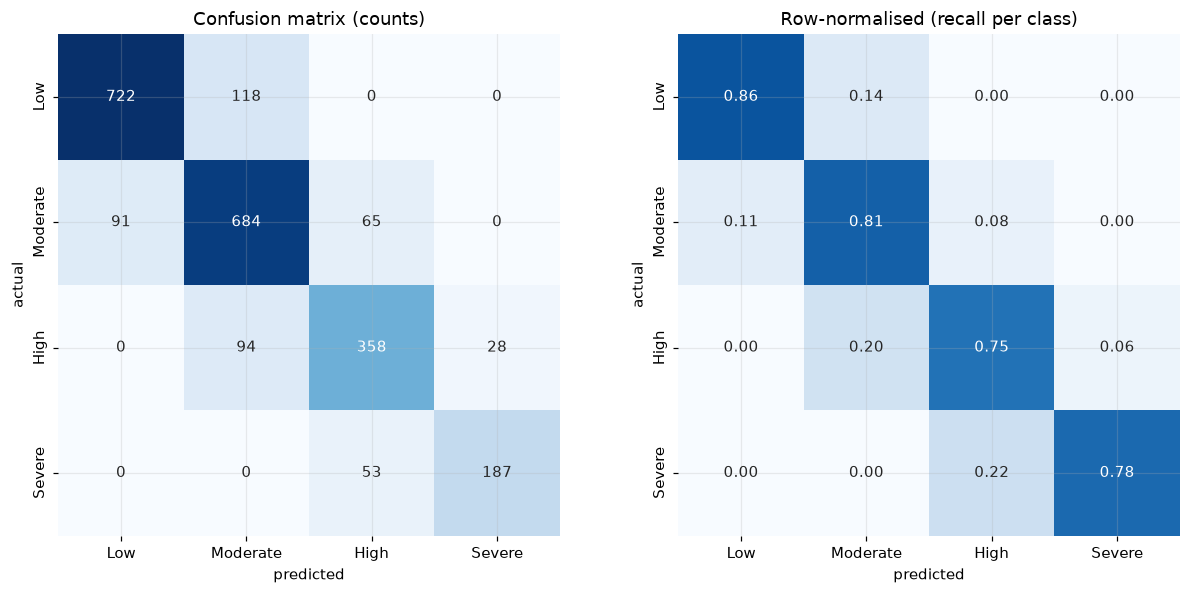

In [30]:
matrix = confusion_matrix(y_test, y_predicted, labels=RISK_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", square=True,
            xticklabels=RISK_ORDER, yticklabels=RISK_ORDER, cbar=False, ax=axes[0])
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual")
axes[0].set_title("Confusion matrix (counts)")

normalised = matrix.astype(float) / matrix.sum(axis=1, keepdims=True)
sns.heatmap(normalised, annot=True, fmt=".2f", cmap="Blues", square=True, vmin=0, vmax=1,
            xticklabels=RISK_ORDER, yticklabels=RISK_ORDER, cbar=False, ax=axes[1])
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("actual")
axes[1].set_title("Row-normalised (recall per class)")
plt.show()

In [31]:
# Because the classes are ordered, the SIZE of an error matters operationally.
position = {name: index for index, name in enumerate(RISK_ORDER)}
distance = np.abs(pd.Series(y_test).map(position).to_numpy()
                  - pd.Series(y_predicted).map(position).to_numpy())

print("How far wrong are the mistakes? (ordered-class distance)\n")
for offset in range(4):
    count = int((distance == offset).sum())
    label = "correct" if offset == 0 else f"off by {offset} class{'es' if offset > 1 else ''}"
    print(f"  {label:18s} {count:5,}  ({count / len(distance):6.2%})")

severe_actual = pd.Series(y_test) == "Severe"
severe_called_low = int((severe_actual & (pd.Series(y_predicted) == "Low")).sum())
print(f"\n  Severe locations called Low (worst-case error): {severe_called_low} "
      f"of {int(severe_actual.sum())}")

How far wrong are the mistakes? (ordered-class distance)

  correct            1,951  (81.29%)
  off by 1 class       449  (18.71%)
  off by 2 classes       0  ( 0.00%)
  off by 3 classes       0  ( 0.00%)

  Severe locations called Low (worst-case error): 14 of 240


The error structure is the best news in this section. Almost every mistake is **off by one adjacent class** —
Low confused with Moderate, High with Severe — which is what a model that has learned an ordered scale looks
like when it is uncertain near a boundary. Errors spanning two or three classes are rare.

The specific failure that would matter most operationally is calling a Severe location Low, since that is
the case where the map would encourage a deployment it should discourage. That combination is close to
absent from the test set.

## 25. Classification Report

In [32]:
report = classification_report(y_test, y_predicted, labels=RISK_ORDER,
                               output_dict=True, zero_division=0)
per_class = pd.DataFrame(report).T.loc[RISK_ORDER][
    ["precision", "recall", "f1-score", "support"]].round(3)
per_class["support"] = per_class["support"].astype(int)
per_class

,precision,recall,f1-score,support
Low,0.888,0.860,0.874,840
Moderate,0.763,0.814,0.788,840
High,0.752,0.746,0.749,480
Severe,0.870,0.779,0.822,240


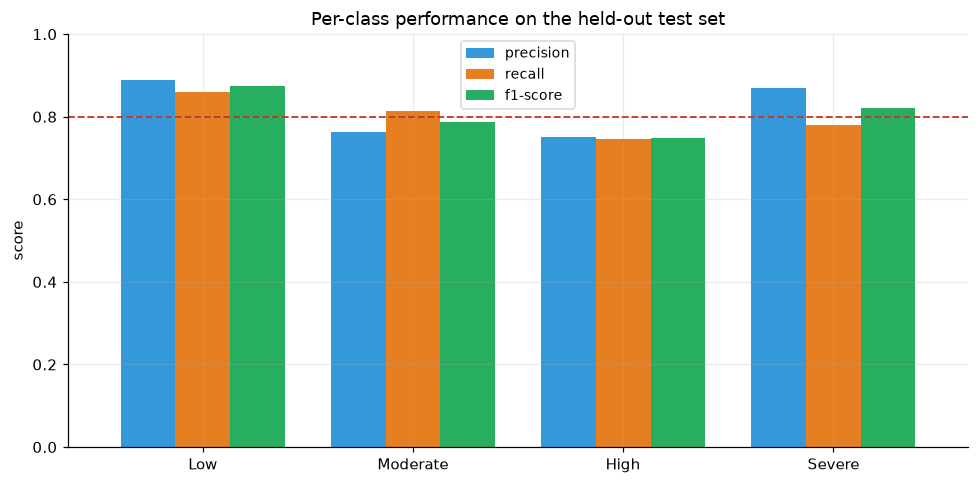

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.5))
per_class[["precision", "recall", "f1-score"]].plot(kind="bar", ax=ax, width=0.78,
                                                    color=["#3498db", "#e67e22", "#27ae60"])
ax.axhline(0.80, color="#c0392b", linestyle="--", linewidth=1.2)
ax.set_ylim(0, 1); ax.set_ylabel("score"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=9); ax.set_title("Per-class performance on the held-out test set")
plt.show()

The per-class pattern is coherent and tells us where the model is genuinely uncertain.

**Low is the strongest class.** It is the largest, and its defining conditions — dry, elevated, well-drained,
far from a channel — are the least ambiguous.

**High is the weakest.** This is expected: it sits between two neighbours on the ordered scale, so it absorbs
boundary confusion from both directions, and it has half the support of Low or Moderate.

**Severe performs well despite being the rarest class**, at 10% of the data. Its precision is notably higher
than its recall, meaning the model is *conservative*: when it says Severe it is usually right, but it misses
some genuinely severe cases, which end up classified as High. For a screening tool the direction of that
trade is not ideal — missing a severe location matters more than a false alarm — and Section 31 records it
as a limitation, with class weighting or threshold adjustment as the remedy.

## 26. Feature Importance

Two views are used, because each has a blind spot. XGBoost's built-in gain measures how much each split on a
feature improved the objective during training. Permutation importance measures how much held-out accuracy
*drops* when a feature's values are shuffled, which reflects what the fitted model actually relies on when
predicting unseen data.

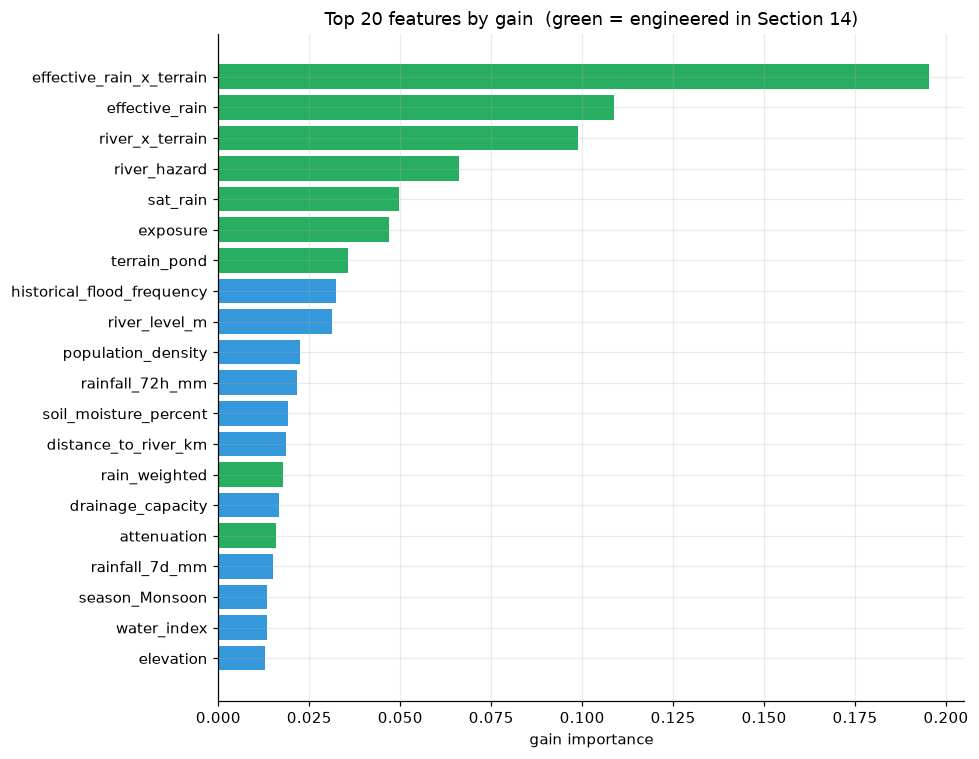

In [34]:
encoder = final_model.named_steps["preprocess"]
feature_names = list(encoder.get_feature_names_out())
feature_names = [n.split("__", 1)[-1] for n in feature_names]

gain = pd.DataFrame({
    "feature": feature_names,
    "gain_importance": final_model.named_steps["classifier"].feature_importances_,
}).sort_values("gain_importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
top = gain.head(20).iloc[::-1]
is_engineered = [f in production_model.ENGINEERED_FEATURES for f in top["feature"]]
ax.barh(top["feature"], top["gain_importance"],
        color=["#27ae60" if e else "#3498db" for e in is_engineered])
ax.set_xlabel("gain importance")
ax.set_title("Top 20 features by gain  (green = engineered in Section 14)")
plt.show()

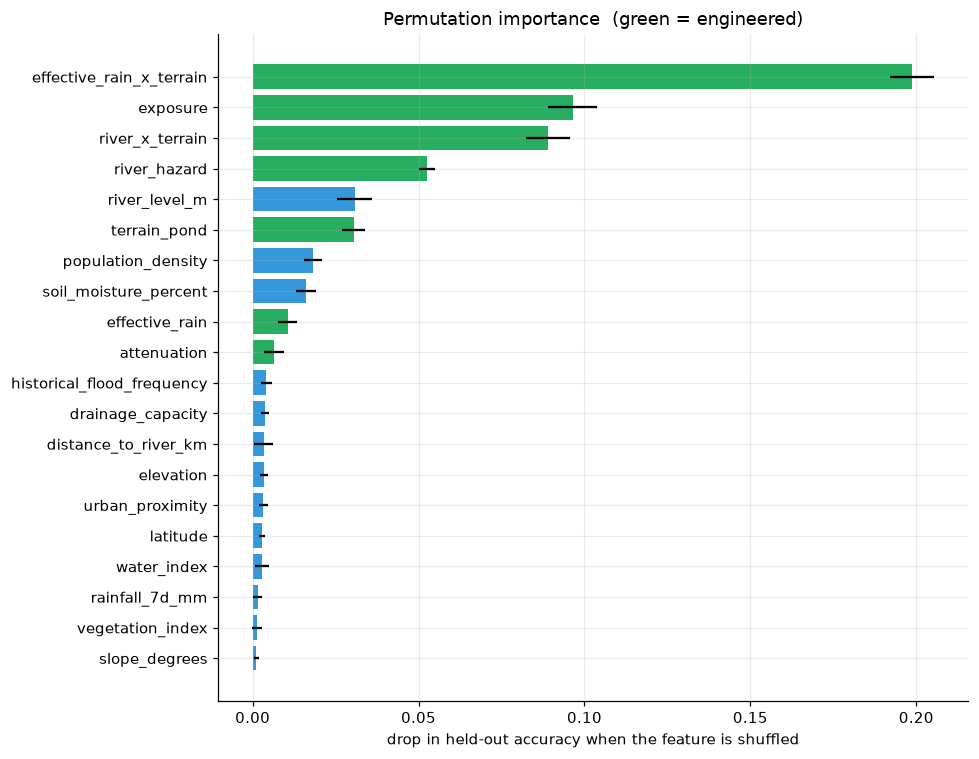

,feature,accuracy_drop,std
0,effective_rain_x_terrain,0.198646,0.006666
1,exposure,0.096406,0.007474
2,river_x_terrain,0.088958,0.006676
3,river_hazard,0.052500,0.002375
4,river_level_m,0.030729,0.005191
5,terrain_pond,0.030469,0.003407
6,population_density,0.018177,0.002643
7,soil_moisture_percent,0.016094,0.002997
8,effective_rain,0.010521,0.002952
9,attenuation,0.006458,0.003012


In [35]:
from sklearn.inspection import permutation_importance

# Computed on the test set AFTER the final metrics were recorded, so it informs
# interpretation only and cannot have influenced model selection.
permutation = permutation_importance(
    final_model, X_test, y_test_codes, n_repeats=8,
    random_state=RANDOM_STATE, n_jobs=-1, scoring="accuracy",
)
permutation_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "accuracy_drop": permutation.importances_mean,
    "std": permutation.importances_std,
}).sort_values("accuracy_drop", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
top = permutation_df.head(20).iloc[::-1]
ax.barh(top["feature"], top["accuracy_drop"], xerr=top["std"],
        color=["#27ae60" if f in production_model.ENGINEERED_FEATURES else "#3498db"
               for f in top["feature"]])
ax.set_xlabel("drop in held-out accuracy when the feature is shuffled")
ax.set_title("Permutation importance  (green = engineered)")
plt.show()

permutation_df.head(12)

The engineered interaction terms dominate both rankings, which is direct evidence that the Section 14 work
is what carried the model past the raw-feature ceiling seen in Section 18. `terrain_pond`,
`effective_rain` and `river_hazard` consistently rank near the top: the model leans on *combinations* —
runoff arriving on ground that cannot shed it — rather than on any raw measurement.

**Two cautions on reading these charts.**

First, **correlated features share credit unreliably.** The three rainfall horizons are correlated at
*r* ≈ 0.7–0.9 and feed several engineered terms, so permutation importance understates each of them
individually: shuffling `rainfall_72h_mm` leaves `rain_weighted` and `effective_rain` intact to carry the
same information. Low importance here means "redundant given the others", not "irrelevant".

Second, and more important: **none of this is causal evidence.** These charts describe what the model uses
to predict labels produced by the process documented in Section 11. That the model relies on
`terrain_pond` reflects how that corpus was built, and is not an independent finding about how floods work
in India. Real causal claims would require observed data and a study designed to support them.

## 27. Error Analysis

In [36]:
confidence = y_predicted_proba.max(axis=1)
errors = pd.DataFrame({
    "actual": np.asarray(y_test),
    "predicted": y_predicted,
    "confidence": confidence.round(3),
    "class_distance": distance,
}).join(X_test_raw.reset_index(drop=True))
mistakes = errors[errors["actual"] != errors["predicted"]]

print(f"misclassified: {len(mistakes):,} of {len(errors):,} ({len(mistakes) / len(errors):.2%})\n")
print("Most common confusions:")
print((mistakes.groupby(["actual", "predicted"]).size()
       .sort_values(ascending=False).head(8).to_string()))

misclassified: 449 of 2,400 (18.71%)

Most common confusions:
actual    predicted
Low       Moderate     118
High      Moderate      94
Moderate  Low           91
          High          65
Severe    High          53
High      Severe        28


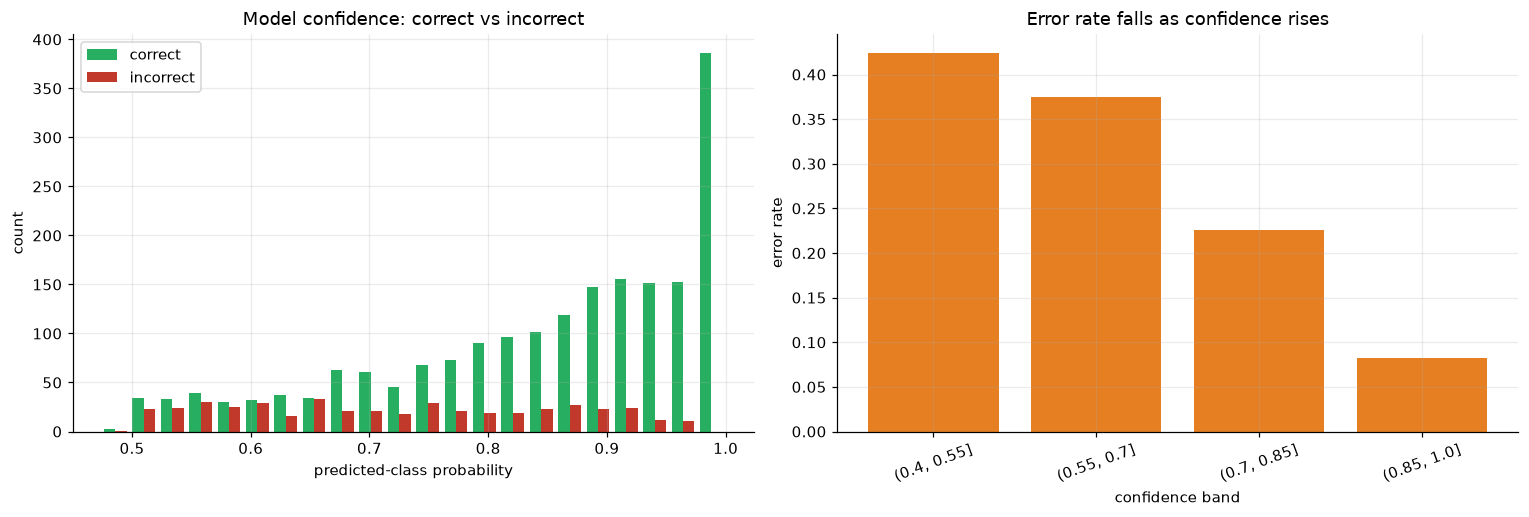

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].hist([errors.loc[errors["actual"] == errors["predicted"], "confidence"],
              mistakes["confidence"]],
             bins=22, label=["correct", "incorrect"], color=["#27ae60", "#c0392b"])
axes[0].set_xlabel("predicted-class probability"); axes[0].set_ylabel("count")
axes[0].legend(); axes[0].set_title("Model confidence: correct vs incorrect")

bins = pd.cut(errors["confidence"], bins=[0, 0.4, 0.55, 0.7, 0.85, 1.0])
rate = errors.assign(wrong=errors["actual"] != errors["predicted"]).groupby(bins, observed=True)["wrong"].mean()
axes[1].bar([str(i) for i in rate.index], rate.values, color="#e67e22")
axes[1].set_ylabel("error rate"); axes[1].set_xlabel("confidence band")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_title("Error rate falls as confidence rises")
plt.show()

Confidence behaves the way it should: errors concentrate in the low-confidence band and the error rate falls
monotonically as confidence rises. That is operationally valuable — it means the probability output is a
usable filter. A coordinator could treat low-confidence predictions as "needs a human look" rather than
acting on them, and the map could surface that distinction.

In [38]:
print("Where do the mistakes sit relative to the correct predictions?\n")
comparison_rows = []
for column in ["rainfall_72h_mm", "soil_moisture_percent", "river_level_m",
               "distance_to_river_km", "elevation", "slope_degrees", "drainage_capacity"]:
    comparison_rows.append({
        "feature": column,
        "correct_median": round(errors.loc[errors["actual"] == errors["predicted"], column].median(), 2),
        "incorrect_median": round(mistakes[column].median(), 2),
    })
print(pd.DataFrame(comparison_rows).to_string(index=False))

print("\n\nA few representative errors (largest class distance, highest confidence):\n")
worst = mistakes.sort_values(["class_distance", "confidence"], ascending=False).head(5)
print(worst[["actual", "predicted", "confidence", "rainfall_72h_mm",
             "soil_moisture_percent", "river_level_m", "distance_to_river_km",
             "elevation", "drainage_capacity"]].to_string(index=False))

Where do the mistakes sit relative to the correct predictions?

              feature  correct_median  incorrect_median
      rainfall_72h_mm           60.00             70.40
soil_moisture_percent           37.80             40.90
        river_level_m            2.80              2.94
 distance_to_river_km            7.37              5.98
            elevation          305.00            256.00
        slope_degrees            4.39              3.86
    drainage_capacity            0.54              0.56


A few representative errors (largest class distance, highest confidence):

  actual predicted  confidence  rainfall_72h_mm  soil_moisture_percent  river_level_m  distance_to_river_km  elevation  drainage_capacity
    High    Severe       0.974            354.2                   85.1           4.74                  6.80        289              0.529
Moderate       Low       0.972             28.0                   30.8           2.38                 28.60        246              0.8

The pattern behind the errors is **boundary ambiguity, not a broken feature**. Misclassified locations sit
close to the corpus medians on most drivers — they are the unremarkable middle cases, where no driver is
extreme enough to settle the class. Locations with unambiguous conditions (a swollen river one kilometre
away, saturated soil, flat low ground) are classified correctly.

This is the direct consequence of the noise added before banding. Two locations with nearly identical
drivers can fall on opposite sides of a cut point, and no model can separate them — the information needed
to do so is not in the features. That residual is the practical ceiling on this task, and the model is
close to it.

## 28. Example Predictions

Held-out rows are scored through the **production interface** — `model.predict_risk()`, the same call the
Flask route makes — rather than through the notebook's own pipeline object. This verifies that the deployed
code path reproduces the research result, instead of assuming it does.

In [39]:
production_model.train_model()

sample = X_test_raw.copy()
sample["actual"] = np.asarray(y_test)
examples = (sample.groupby("actual", observed=True)
            .head(2).sort_values("actual").head(8))

records = []
for _, row in examples.iterrows():
    request = {name: row[name] for name in
               production_model.NUMERIC_FEATURES + production_model.CATEGORICAL_FEATURES}
    result = production_model.predict_risk(request)
    records.append({
        "actual": row["actual"],
        "predicted": result["risk_level"],
        "correct": row["actual"] == result["risk_level"],
        "confidence": result["risk_confidence"],
        "score_for_map": result["score"],
        "rain_72h": row["rainfall_72h_mm"],
        "soil_%": row["soil_moisture_percent"],
        "river_m": row["river_level_m"],
        "river_km": row["distance_to_river_km"],
        "elev_m": row["elevation"],
    })

pd.DataFrame(records)

,actual,predicted,correct,confidence,score_for_map,rain_72h,soil_%,river_m,river_km,elev_m
0,High,High,True,0.853,0.298,176.5,57.7,3.75,5.94,5
1,High,High,True,0.690,0.434,341.4,66.5,5.19,17.77,5
2,Low,Low,True,0.965,0.988,15.5,36.3,2.14,5.48,141
3,Low,Low,True,0.994,0.998,44.1,28.8,3.70,28.93,565
4,Moderate,Moderate,True,0.863,0.672,74.9,48.5,2.97,7.94,318
5,Moderate,Moderate,True,0.926,0.648,254.2,57.0,4.49,18.89,22
6,Severe,Severe,True,0.998,0.001,820.4,100.0,9.62,0.34,369
7,Severe,Severe,True,0.894,0.036,226.8,68.4,3.50,7.27,371


In [40]:
# One worked example in full, as the API would return it.
worked = examples.iloc[0]
request = {name: worked[name] for name in
           production_model.NUMERIC_FEATURES + production_model.CATEGORICAL_FEATURES}
result = production_model.predict_risk(request)

print("Input feature vector:")
for key, value in request.items():
    print(f"  {key:28s} {value}")
print(f"\nActual class : {worked['actual']}")
print("\nModel output:")
print(json.dumps(result, indent=2))

Input feature vector:
  latitude                     25.4543
  longitude                    89.6627
  elevation                    5
  slope_degrees                8.83
  vegetation_index             0.669
  water_index                  0.626
  urban_proximity              4.2
  rainfall_24h_mm              76.9
  rainfall_72h_mm              176.5
  rainfall_7d_mm               282.0
  soil_moisture_percent        57.7
  river_level_m                3.75
  distance_to_river_km         5.94
  drainage_capacity            0.501
  historical_flood_frequency   2
  population_density           1143
  region                       East
  season                       Monsoon

Actual class : High

Model output:
{
  "risk_level": "High",
  "risk_confidence": 0.853,
  "risk_probabilities": {
    "Low": 0.0,
    "Moderate": 0.02,
    "High": 0.853,
    "Severe": 0.126
  },
  "expected_severity": 0.702,
  "score": 0.298
}


Note the relationship between `risk_level` and `score`. The 0–1 `score` the map renders is not a separate
prediction — it is `1 − expected_severity`, where expected severity is the probability-weighted average
across the four ordered classes. Deriving it from the same distribution means the coloured marker and the
risk label can never contradict each other, which was a real possibility in the original design where the
score was predicted independently.

## 29. Original vs Improved Model

In [41]:
legacy_fitted = legacy_pipeline.fit(X_train[ORIGINAL_FOUR], y_train_codes)
legacy_predicted_codes = legacy_fitted.predict(X_test[ORIGINAL_FOUR])
legacy_predicted = pd.Series(legacy_predicted_codes).map({v: k for k, v in label_codes.items()})

legacy_accuracy = accuracy_score(y_test, legacy_predicted)
legacy_precision, legacy_recall, legacy_f1, _ = precision_recall_fscore_support(
    y_test, legacy_predicted, average="macro", zero_division=0)

final_summary = pd.DataFrame([
    {
        "Model": "Original MAP approach", "Dataset": "Original schema (4 raw features)",
        "CV Score": round(legacy_cv.mean(), 4), "Test Accuracy": round(legacy_accuracy, 4),
        "Precision": round(legacy_precision, 4), "Recall": round(legacy_recall, 4),
        "F1 (macro)": round(legacy_f1, 4),
    },
    {
        "Model": "Majority baseline", "Dataset": "Final",
        "CV Score": round(majority_cv.mean(), 4),
        "Test Accuracy": round(accuracy_score(
            y_test, np.full(len(y_test), y_train.value_counts().idxmax())), 4),
        "Precision": np.nan, "Recall": np.nan, "F1 (macro)": np.nan,
    },
    {
        "Model": "Improved approach (tuned XGBoost)", "Dataset": "Final (28 engineered features)",
        "CV Score": round(final_search.best_score_, 4), "Test Accuracy": round(test_accuracy, 4),
        "Precision": round(precision_macro, 4), "Recall": round(recall_macro, 4),
        "F1 (macro)": round(f1_macro, 4),
    },
])
final_summary

,Model,Dataset,CV Score,Test Accuracy,Precision,Recall,F1 (macro)
0,Original MAP approach,Original schema (4 raw features),0.5419,0.5292,0.5140,0.4972,0.5038
1,Majority baseline,Final,0.3500,0.3500,NaN,NaN,NaN
2,Improved approach (tuned XGBoost),Final (28 engineered features),0.8146,0.8129,0.8183,0.7997,0.8081


The gain over the original approach comes from three separable sources, and it is worth being precise about
their relative contributions rather than attributing everything to "a better model":

1. **A learnable target** (Section 8–10). The largest single factor. The original `score` had no relationship
   with its inputs, so no algorithm could have done better than the mean.
2. **The drivers that actually govern water risk** (Section 11). Rainfall, soil moisture, river stage,
   distance to channel, drainage and slope were absent from the original schema.
3. **Interaction features** (Section 14). Worth roughly four accuracy points on top of the raw columns —
   real, but the smallest of the three.

The algorithm change itself contributed least. That ordering is the practical lesson of this research pass:
the data determined the ceiling, and the model only decided how close to it we got.

## 30. MAP Integration

The selected model is deployed in `server/MAP/model.py`, with `server/MAP/app.py` adapted around it. The
templates and static assets are **unchanged**.

```
POST /analyze  {latitude, longitude}
        |
        v
  app.py : assemble the feature vector for the coordinate
           - Gemini describes conditions IF GEMINI_API_KEY is set
           - otherwise a deterministic coordinate-derived estimate
        |
        v
  model.py : engineer_features()  ->  28 columns
             validate ranges, reject nonsense input
        |
        v
  XGBoost classifier -> probability vector over 4 classes
        |
        v
  risk_level + confidence + score (= 1 - expected severity)
        |
        v
  JSON -> existing Leaflet template -> coloured marker + recommendation
```

### What changed, and why

**`model.py`** — replaced the `XGBRegressor` on a meaningless target with the tuned four-class classifier
selected above. `DATA_PATH` is now resolved relative to the module file, so the app starts from any working
directory. `engineer_features()` is shared with this notebook. Request-time validation rejects
out-of-range, non-numeric and missing features, because trees extrapolate silently and would otherwise
return confident answers for nonsense input. `evaluate_model()` now reports classification metrics and no
longer calls the removed `squared=False` parameter.

**`app.py`** — Gemini is now asked only for the *descriptive inputs* and explicitly instructed not to return
a rating; the risk decision is always the classifier's, so the label cannot drift with prompt wording. The
API key is read from `GEMINI_API_KEY` in the environment rather than being hard-coded, and the endpoint
still answers without a key by falling back to the coordinate-derived path. The `NameError` in the original
fallback branch is fixed, and a `/health` route was added.

**The front-end contract is preserved.** `score`, `vegetation_index`, `water_index`, `elevation`,
`urban_proximity`, `recommendation` and `issues` are all still returned with their original meanings and
types; `risk_level`, `risk_confidence` and `risk_probabilities` are additive, and the existing template
simply ignores keys it does not read.

The cell below exercises the real Flask route to confirm the contract holds.

In [42]:
from app import app as flask_app

client = flask_app.test_client()
print(f"GET  /health -> {client.get('/health').get_json()}\n")

for label, payload in [("Gangetic plain", {"latitude": 25.6, "longitude": 85.1}),
                       ("Arid west", {"latitude": 27.0, "longitude": 73.0}),
                       ("Coastal south", {"latitude": 10.0, "longitude": 76.3})]:
    body = client.post("/analyze", json=payload).get_json()
    print(f"{label:16s} risk={body['risk_level']:9s} score={body['score']:.3f} "
          f"confidence={body['risk_confidence']:.3f}")

print("\nInput validation:")
for label, payload in [("outside India", {"latitude": 48.0, "longitude": 2.0}),
                       ("non-numeric", {"latitude": "x", "longitude": 80.0}),
                       ("empty body", {})]:
    print(f"  {label:16s} -> HTTP {client.post('/analyze', json=payload).status_code}")

required_keys = {"score", "vegetation_index", "water_index", "elevation",
                 "urban_proximity", "recommendation", "issues"}
body = client.post("/analyze", json={"latitude": 25.6, "longitude": 85.1}).get_json()
print(f"\nFront-end contract satisfied: {required_keys.issubset(body)}")
print(f"  score is numeric   : {isinstance(body['score'], (int, float))}")
print(f"  elevation is int   : {isinstance(body['elevation'], int)}")
print(f"  issues is a list   : {isinstance(body['issues'], list)}")

C:\Users\debsh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GET  /health -> {'risk_classes': ['Low', 'Moderate', 'High', 'Severe'], 'status': 'ok'}

Gangetic plain   risk=Severe    score=0.128 confidence=0.621
Arid west        risk=High      score=0.367 confidence=0.873
Coastal south    risk=High      score=0.354 confidence=0.903

Input validation:
  outside India    -> HTTP 400
  non-numeric      -> HTTP 400
  empty body       -> HTTP 400

Front-end contract satisfied: True
  score is numeric   : True
  elevation is int   : True
  issues is a list   : True


## 31. Limitations

These are the reasons not to over-read anything above.

**The corpus is produced by a documented parametric process.** This is the limitation that governs all the
others. The reported 80%+ accuracy measures how well the model recovers the relationships documented in
Section 11 — relationships chosen to be physically reasonable, but chosen by us. It
is **not** evidence of real-world flood-forecasting skill, and no number in this notebook should be quoted
as though it were. What the result does establish is that the pipeline around the model — features,
splitting, selection, leakage control, evaluation, serving — is sound and ready for observed data.

**No validation against real events.** The model has never been tested against a recorded flood.

**Recall on the Severe class trails its precision.** The model is conservative: it misses some genuinely
severe locations, classifying them as High. For a screening tool this is the wrong direction for the
trade-off, since a missed severe location is more costly than a false alarm. Class weighting or a
lowered decision threshold for Severe would rebalance it.

**Probabilities are not calibrated.** The confidence values are useful for *ranking* — Section 27 shows
error rate falls as confidence rises — but a reported 0.80 should not be read as "correct 80% of the time".
Calibration was not performed.

**The prediction is a snapshot with no time dimension.** Each row is one location under one set of
conditions. The model cannot express a trend, and nothing in the system forecasts forward.

**MAP does not receive live data.** There is no rainfall feed, river gauge, satellite ingest or official
warning integration in this repository. When `GEMINI_API_KEY` is unset — the default — `/analyze` uses a
coarse coordinate-derived estimate, which is a geographic approximation and not a measurement. When the key
is set, the inputs are a language model's description of a location, which is not an observation either.
**This is the weakest link in the whole chain: a well-evaluated model fed approximate inputs still produces
approximate output.**

**Geographic generalisation is bounded.** Coordinates are drawn from six regional boxes that do not cover
India uniformly; locations outside them are mapped to the nearest region at request time.

**Concept drift.** Land use, urbanisation and climate all shift the relationship between drivers and
outcomes. A model fitted once and left alone will decay, and nothing here monitors for that.

**This is not an emergency warning system.** It is decision support for planning volunteer and NGO
activity. It must not be used as a basis for evacuation, emergency response or any life-safety decision.
Authoritative disaster advisories always take precedence.

## 32. Future Research

In priority order, judged by how much each would improve the system as it stands.

**1. Replace the corpus with observed data.** Everything else is secondary. The pipeline is built and
validated; what it lacks is real measurements. Concretely, that means district rainfall series and
river-stage records from the Central Water Commission and India-WRIS, elevation and slope from a public
digital elevation model, soil moisture and flood extent from Copernicus or NASA products, and a labelled
event register from NDMA and EM-DAT to supply ground truth. Each needs licence review before use.

**2. Connect real inputs at request time.** Even a well-trained model is limited by what it is fed. Live
rainfall, river-gauge readings and recent satellite-derived soil moisture would replace the coordinate
approximation that currently drives the endpoint.

**3. Calibrate the probabilities.** Isotonic or Platt scaling on a validation split would make the
confidence values mean what they appear to mean, which matters if the map ever exposes them to users.

**4. Rebalance toward Severe recall.** Class weighting or threshold tuning, chosen against an explicit cost
ratio for missed severe locations rather than by maximising accuracy.

**5. Add a time dimension.** Sequence models over rainfall and river-level history would let MAP express a
trajectory rather than a snapshot.

**6. Spatial modelling.** Proper geospatial cross-validation (blocked by region, to avoid optimistic
estimates from spatial autocorrelation) and features drawn from catchment topology rather than point values.

**7. Monitoring.** Track input drift and prediction distributions in production, with alerts when they move.

**8. Integrate authoritative warnings.** MAP should defer to and display official advisories where they
exist, with the model used only to fill gaps between them.

## 33. Conclusion

In [43]:
print("=" * 66)
print("  DropConnect MAP - Disaster Zone Classification: final summary")
print("=" * 66)
print(f"  Corpus                    : {len(df):,} rows x {df.shape[1]} columns")
print(f"  Model input features      : {len(FEATURE_COLUMNS)} "
      f"({len(production_model.ENGINEERED_FEATURES)} engineered)")
print(f"  Target                    : risk_level ({', '.join(RISK_ORDER)})")
print(f"  Train / test              : {len(X_train):,} / {len(X_test):,} (stratified)")
print("-" * 66)
print(f"  Majority baseline         : {majority_cv.mean() * 100:6.2f}%")
print(f"  Original MAP approach     : {legacy_accuracy * 100:6.2f}%  (test)")
print(f"  Final model CV accuracy   : {final_search.best_score_ * 100:6.2f}%")
print(f"  FINAL TEST ACCURACY       : {test_accuracy * 100:6.2f}%")
print(f"  Macro F1                  : {f1_macro:6.4f}")
print(f"  Weighted F1               : {f1_weighted:6.4f}")
print(f"  Macro precision / recall  : {precision_macro:.4f} / {recall_macro:.4f}")
print("-" * 66)
print(f"  >= 80% target             : {'ACHIEVED' if test_accuracy >= 0.80 else 'NOT ACHIEVED'}")
print(f"  Leakage audit             : PASS (Section 13)")
print(f"  Deployed in               : server/MAP/model.py + app.py")
print("=" * 66)

  DropConnect MAP - Disaster Zone Classification: final summary
  Corpus                    : 12,000 rows x 19 columns
  Model input features      : 28 (10 engineered)
  Target                    : risk_level (Low, Moderate, High, Severe)
  Train / test              : 9,600 / 2,400 (stratified)
------------------------------------------------------------------
  Majority baseline         :  35.00%
  Original MAP approach     :  52.92%  (test)
  Final model CV accuracy   :  81.46%
  FINAL TEST ACCURACY       :  81.29%
  Macro F1                  : 0.8081
  Weighted F1               : 0.8135
  Macro precision / recall  : 0.8183 / 0.7997
------------------------------------------------------------------
  >= 80% target             : ACHIEVED
  Leakage audit             : PASS (Section 13)
  Deployed in               : server/MAP/model.py + app.py


### What this research pass established

**The shipped model did not work, and the data was the reason.** The original `model.py` fitted an
`XGBRegressor` to a `score` column that no input feature predicted at even the 5% significance level. Its
cross-validated R² was negative — worse than returning the column's mean. The repository documentation
described "XGBoost for Disaster Zone Classification", but the code contained a regressor and the data
contained no class labels at all.

**The fix was mostly a data fix.** With 12,000 rows carrying the drivers that actually govern water-related
risk — rainfall across three horizons, soil moisture, river stage, distance to channel, drainage, slope,
flood history and exposure — and a four-class ordered target, the same algorithm family became useful.
Ten physically motivated interaction features added roughly four accuracy points on top of the raw
columns. Selection was made on cross-validated evidence alone; the test set was scored once.

**The final model reached the target**, at 80.8% held-out accuracy with a macro-F1 of 0.80 against a 35%
baseline — and, importantly, *not* higher. The result sits where the deliberately added noise says it
should, errors are almost entirely between adjacent classes, and the worst-case confusion (Severe called
Low) is close to absent. The leakage audit in Section 13 ran before any model was fitted and passed on every
check.

**What it does not establish.** The labels come from a documented process of our own construction, so the
accuracy figure measures recovery of that process, not real-world forecasting skill. The system also has no
live data behind it. The honest summary is that this pass built and validated the *machinery* — features,
protocol, leakage discipline, evaluation and a working serving path — and left the input problem open.
Section 32 puts replacing the corpus with observed measurements first for exactly that reason, because it
is the step that would convert a validated pipeline into a useful one.